# Reduced-budget ICL runs — what the cp26 and ac1 campaigns say

Nine campaign directories under `src/runs/`, every run matched at **1,200 candidates**: Best-of-N, plain PUCT,
and three in-prompt context strategies, on `circle_packing_26` (gpt-oss-120B and Qwen3.6-27B) and on
`ac1` (gpt-oss-120B only).

| arm | parent source | `n_context` | shape |
|---|---|---|---|
| **BoN** | `initial` — every candidate branches off the seed | 0 | 1 gen x 75 parents x 16 children |
| **PUCT** | PUCT over the buffer | 0 | 15 gens x 5 parents x 16 |
| **ICL** `best` / `random` / `contrastive` | PUCT | 10 (or 5) | 15 gens x 5 x 16 |

`best` = top-k by value, `random` = uniform shuffle, `contrastive` = MMR-diverse positives plus
MMR-ranked *worst* attempts as negatives (`context/selection.py`).

Because every arm spends exactly 80 candidates per generation, **generation *g* = candidates
80(g+1)**, and Best-of-N — which has no generations — drops onto the same axis in blocks of 80. That
gives one common budget axis for all arms.

**The findings:**

1. cp26: every search arm beats Best-of-N, and PUCT-vs-context is inside the noise · 2. cp26 is
saturated, so convergence *speed* is the metric — only the `best` context strategy leads early, and
PUCT overtakes it by k≈160 ·
3. the growing timeouts are the **solutions getting slower**, not the machine, and the cap censors
exactly the good candidates · 4. on ac1 the same symptom has the *opposite* cause — a 9% margin bug
that makes the failure rate unattributable · 5. on ac1, **PUCT ≈ BoN** on 4 seeds, and the best runs
are all ICL on 1 seed · 6. context costs 8.4x the prefill and turns generation into editing ·
7. every Qwen failure count is infra-corrupted, provably — but Qwen-27B still out-scores gpt-oss-120B
on Best-of-N.

In [1]:
import json, os, glob, collections, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.patches import Patch

RUNS = "../runs" if os.path.basename(os.getcwd()) == "notebooks" else "runs"

CAP = {"circle_packing_26": 530, "ac1": 1100}       # envs/registry.py:30,32 — hard eval timeout
TARGET = {"circle_packing_26": 2.636, "ac1": 1.5030}  # value the prompt asks the model to beat
MAXIMIZE = {"circle_packing_26": True, "ac1": False}
ATTRACTOR = 2.6359830849                             # cp26 near-optimum every good run lands on
AC1_BUDGET_S = 1000                                  # envs/ac_inequalities.py:259 — told to the model
BUDGET = 1200                                        # candidates per run, identical in every arm
GEN = 80                                             # candidates per generation, identical too

plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "legend.frameon": False, "figure.autolayout": True})
CSEED = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
CMEAN, CREF = "#22223B", "#B0B0B0"
CARM = {"BoN": "#937860", "PUCT": "#22223B", "ICL best": "#DD8452",
        "ICL random": "#55A868", "ICL contrastive": "#8172B3"}
FAIL_ORDER = ["valid", "eval_timeout", "process_crash", "invalid_result", "no_code"]
CFAIL = dict(zip(FAIL_ORDER, ["#55A868", "#C44E52", "#DD8452", "#8172B3", "#937860"]))


# --------------------------------------------------------------------------- loading
def _iso(s):
    return dt.datetime.fromisoformat(s) if s else None

def inventory():
    # One row per run over runs/<group>/<run>/, joining summary.json knobs with config.json host.
    rows = []
    for s in sorted(glob.glob(os.path.join(RUNS, "*", "*", "summary.json"))):
        d_run = os.path.dirname(s)
        group, run = os.path.basename(os.path.dirname(d_run)), os.path.basename(d_run)
        d = json.load(open(s))
        cfg = json.load(open(os.path.join(d_run, "config.json")))
        n = sum(1 for _ in open(os.path.join(d_run, "events.jsonl")))
        u = d.get("usage") or {}
        rows.append(dict(
            group=group, run=run, problem=d["problem"],
            model="gpt-oss-120B" if "gpt-oss" in cfg["model_name"] else "Qwen3.6-27B",
            host=(cfg["_meta"]["host"] or "").split(".")[0],
            strategy=d["strategy"], n_context=d["n_context"], seed=cfg["seed"],
            gens_done=len(d.get("per_generation") or []), gens_asked=d["num_generations"],
            candidates=n, best=(d.get("best") or {}).get("score"), status=d["status"],
            started=_iso(d.get("started_at")), updated=_iso(d.get("updated_at")),
            wall_h=sum(g.get("wall_seconds") or 0 for g in (d.get("per_generation") or [])) / 3600,
            prompt_tok=u.get("prompt_tokens"), compl_tok=u.get("completion_tokens"),
            reason_tok=u.get("reasoning_tokens"), truncated=u.get("truncated"),
            failures=(d.get("totals") or {}).get("failure_types") or {},
        ))
    df = pd.DataFrame(rows)
    # arm label: BoN when every parent is the seed, else PUCT, else ICL + strategy
    def arm(r):
        if r.gens_asked == 1:
            return "BoN"
        return f"ICL {r.strategy}" if r.n_context else "PUCT"
    df["arm"] = df.apply(arm, axis=1)
    df["n_ctx_label"] = np.where(df.n_context > 0, "n=" + df.n_context.astype(str), "—")
    df["complete"] = df.gens_done >= df.gens_asked
    return df.sort_values(["problem", "model", "arm", "n_context", "seed"]).reset_index(drop=True)


def events(group, run):
    # Every candidate of one run, in completion order.
    #  valid  -- the definition used throughout: correctness == 1.0 AND a non-null raw_score.
    #            (failure_type is the empty string, not null, on success -- hence the replace)
    #  block  -- (k-1)//80, the common budget axis: equals `generation` for PUCT/ICL, and gives
    #            Best-of-N a comparable 15-block axis since every generation is exactly 80.
    df = pd.DataFrame([json.loads(l) for l in open(os.path.join(RUNS, group, run, "events.jsonl"))])
    df["valid"] = (df.correctness == 1.0) & df.raw_score.notna()
    df["failure_type"] = df.failure_type.replace("", np.nan)
    df["outcome"] = np.where(df.valid, "valid", df.failure_type.fillna("unknown"))
    df["k"] = np.arange(1, len(df) + 1)
    df["block"] = (df.k - 1) // GEN
    return df


def best_so_far(vals, maximize):
    # Running best over a per-candidate score array, failures = nan. Maximise -> running max clipped
    # at 0 (a failure scores 0); minimise -> running min, +inf until the first valid candidate.
    a = np.asarray(vals, float)
    if maximize:
        return np.fmax.accumulate(np.nan_to_num(a, nan=-np.inf)).clip(min=0.0)
    return np.fmin.accumulate(np.nan_to_num(a, nan=np.inf))


INV = inventory()
CACHE = {}
def arm_runs(problem, model, arm, n_context=None):
    # [(seed_label, events_df)] for one arm, seed-ordered. Cached, because §5 re-reads these a lot.
    q = INV[(INV.problem == problem) & (INV.model == model) & (INV.arm == arm)]
    if n_context is not None:
        q = q[q.n_context == n_context]
    out = []
    for r in q.sort_values("seed").itertuples():
        key = (r.group, r.run)
        if key not in CACHE:
            CACHE[key] = events(*key)
        out.append((f"s{r.seed}", CACHE[key]))
    return out


def runs_of(problem, model=None):
    # [(inventory_row, events_df)] -- use when the analysis needs the run's host / knobs alongside
    # its candidates (the eval-time sections all do).
    q = INV[INV.problem == problem]
    if model:
        q = q[q.model == model]
    out = []
    for r in q.itertuples():
        key = (r.group, r.run)
        if key not in CACHE:
            CACHE[key] = events(*key)
        out.append((r, CACHE[key]))
    return out


def curves(problem, model, arm, n_context=None):
    # {seed_label: best-so-far array} for one arm, each truncated to its real candidate count.
    mx = MAXIMIZE[problem]
    return {lab: best_so_far(np.where(d.valid, d.raw_score, np.nan), mx)
            for lab, d in arm_runs(problem, model, arm, n_context)}


def pad(c, n=BUDGET):
    # Stretch one best-so-far curve to the full budget by holding its last value -- the honest
    # extension for a run that is still in flight (it cannot get worse than where it stopped).
    return np.concatenate([c, np.full(max(0, n - len(c)), c[-1])])[:n]


def mean_curve(cs, n=BUDGET):
    # Mean over seeds at each k, holding each short run at its last value (runs still in flight).
    if not cs:
        return np.full(n, np.nan)
    return np.mean([pad(c, n) for c in cs.values()], axis=0)


print(f"{len(INV)} runs, {INV.candidates.sum():,} candidates on disk")
print(INV.groupby(["problem", "model"]).agg(runs=("run", "size"), cands=("candidates", "sum")).to_string())

48 runs, 52,096 candidates on disk
                                runs  cands
problem           model                    
ac1               gpt-oss-120B    18  17600
circle_packing_26 Qwen3.6-27B     10  10496
                  gpt-oss-120B    20  24000


## 0. What was actually run — and the confound to keep in view

Two things to read off the table below before any comparison.

**Completeness.** cp26/gpt-oss is complete (4 seeds x 5 arms). cp26/Qwen has 4 BoN seeds but only 1–2
complete ICL seeds per strategy. ac1 has 4 PUCT seeds and 4 BoN seeds, but the ICL arms are **1 seed**
(plus mid-flight partials). Every ac1 ICL claim in this notebook is therefore *suggestive, not
significant*, and is flagged where it appears.

**The machine confound.** These campaigns were spread over seven boxes. On cp26, PUCT ran on `guadiana`
and the ICL arms on `vouga`; on ac1, every arm sits on a different host. And all Qwen runs ran on the
Bosch **login node**, whose cgroup caps the user slice at 5 cores while exposing 64 —
a confirmed **11.5x** eval slowdown (`docs/BOSCH_CLUSTER.md`). Score comparisons survive this;
eval-time and failure-rate comparisons do not, unless made within one host. Section 5 turns that
into a measurement instead of a caveat.

In [2]:
show = INV[["problem", "model", "arm", "n_ctx_label", "seed", "host", "gens_done", "gens_asked",
            "candidates", "best", "status", "wall_h"]].rename(columns={"n_ctx_label": "n_ctx"})
display(show.style.format({"best": "{:.5f}", "wall_h": "{:.1f}"}).hide(axis="index"))

comp = (INV.groupby(["problem", "model", "arm", "n_ctx_label"])
          .agg(seeds=("seed", "nunique"), complete=("complete", "sum"),
               cands=("candidates", "sum"), hosts=("host", lambda s: ",".join(sorted(set(s)))))
          .reset_index())
print("\ncompleteness by arm")
print(comp.to_string(index=False))

problem,model,arm,n_ctx,seed,host,gens_done,gens_asked,candidates,best,status,wall_h
ac1,gpt-oss-120B,BoN,—,1,guadiana,1,1,1200,1.51551,complete,3.5
ac1,gpt-oss-120B,BoN,—,2,guadiana,1,1,1200,1.51214,complete,2.9
ac1,gpt-oss-120B,BoN,—,3,guadiana,1,1,1200,1.51573,complete,2.9
ac1,gpt-oss-120B,BoN,—,4,guadiana,1,1,1200,1.51833,complete,3.1
ac1,gpt-oss-120B,ICL best,n=5,1,cavado,15,15,1200,1.50952,complete,11.4
ac1,gpt-oss-120B,ICL best,n=10,1,guadiana,15,15,1200,1.50643,complete,8.8
ac1,gpt-oss-120B,ICL best,n=10,2,guadiana,5,15,400,1.51256,running,2.4
ac1,gpt-oss-120B,ICL best,n=10,3,tamega,2,15,160,1.51853,running,2.1
ac1,gpt-oss-120B,ICL contrastive,n=5,1,cavado,15,15,1200,1.51468,complete,11.7
ac1,gpt-oss-120B,ICL contrastive,n=10,1,guadiana,13,15,1040,1.51659,running,7.4



completeness by arm
          problem        model             arm n_ctx_label  seeds  complete  cands           hosts
              ac1 gpt-oss-120B             BoN           —      4         4   4800        guadiana
              ac1 gpt-oss-120B        ICL best        n=10      3         1   1760 guadiana,tamega
              ac1 gpt-oss-120B        ICL best         n=5      1         1   1200          cavado
              ac1 gpt-oss-120B ICL contrastive        n=10      1         0   1040        guadiana
              ac1 gpt-oss-120B ICL contrastive         n=5      1         1   1200          cavado
              ac1 gpt-oss-120B      ICL random        n=10      3         1   1600 guadiana,tamega
              ac1 gpt-oss-120B      ICL random         n=5      1         1   1200          cavado
              ac1 gpt-oss-120B            PUCT           —      4         4   4800     lima,zezere
circle_packing_26  Qwen3.6-27B             BoN           —      4         4   4800 rng-d

whole campaign spans 45.1 h

concurrent runs on the same host, by campaign:
                           runs  median_peers  max_peers
group                                                   
ac1_gptoss                    4           1.5          2
ac1_gptoss_rest               9           2.0          2
ac1_gptoss_rest_rest          3           2.0          2
ac1_gptoss_rest_rest_rest     2           1.5          2
bon_gptoss                    4           2.5          4
bon_qwen                      4           3.0          4
ctx_gptoss                   12           2.0          2
ctx_qwen                      6           2.0          4
puct_gptoss                   4           2.5          4

overlapping run-pairs within a campaign, by whether they share a strategy:
  ac1_gptoss                   2 same-config,   0 different-config
  ac1_gptoss_rest              0 same-config,   5 different-config
  ac1_gptoss_rest_rest         0 same-config,   2 different-config
  ac1_gptoss_rest_re

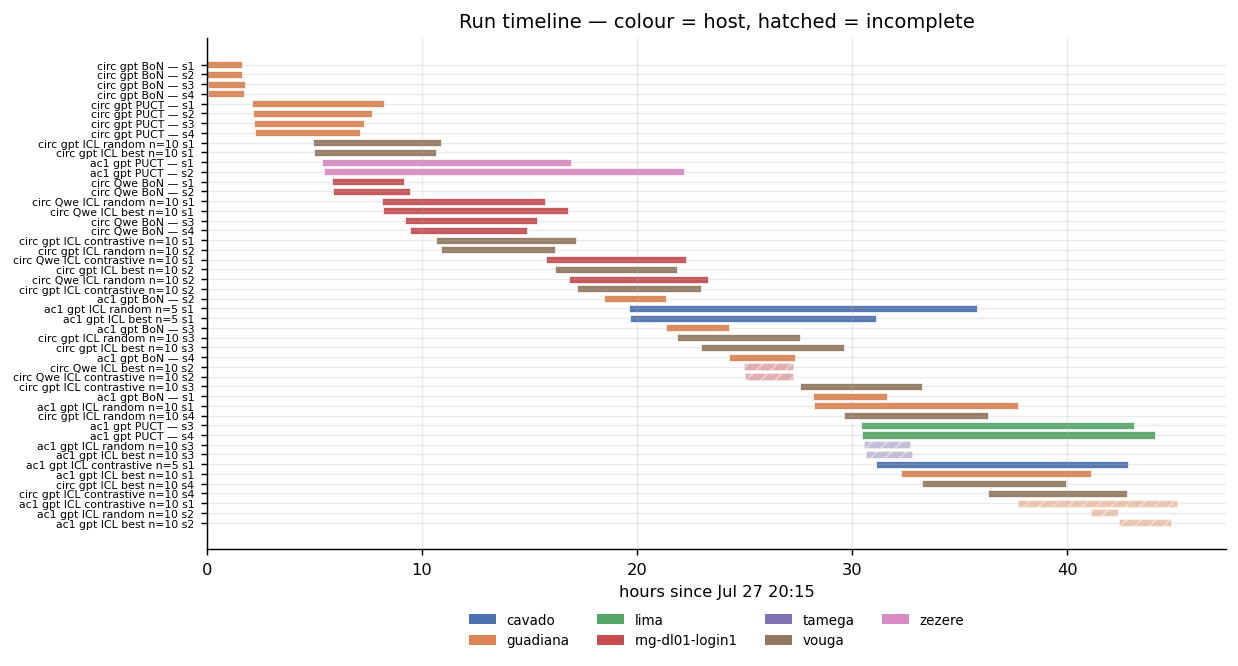

In [3]:
# wall-clock Gantt: which runs overlapped, and on which box
fig, ax = plt.subplots(figsize=(9.6, 5.2))
hosts = sorted(INV.host.unique())
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"]
CHOST = {h: PALETTE[i % len(PALETTE)] for i, h in enumerate(hosts)}
rows = INV.sort_values(["started"]).reset_index(drop=True)
t0 = rows.started.min()
for i, r in rows.iterrows():
    x = (r.started - t0).total_seconds() / 3600
    w = max((r.updated - r.started).total_seconds() / 3600, .05)
    ax.barh(i, w, left=x, height=.72, color=CHOST[r.host],
            alpha=.95 if r.complete else .45,
            hatch="" if r.complete else "///", edgecolor="white", lw=.4)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{r.problem[:4]} {r.model[:3]} {r.arm} {r.n_ctx_label} s{r.seed}"
                    for r in rows.itertuples()], fontsize=6)
ax.invert_yaxis()
ax.set(xlabel=f"hours since {t0:%b %d %H:%M}",
       title="Run timeline — colour = host, hatched = incomplete")
ax.legend(handles=[Patch(fc=CHOST[h], label=h) for h in hosts], fontsize=7.5, ncol=4,
          loc="upper center", bbox_to_anchor=(.5, -.10))
fig.savefig("mf_timeline.png", dpi=200, bbox_inches="tight")

rows["peers"] = [sum(1 for o in rows.itertuples()
                     if o.host == r.host and o.started <= r.started <= o.updated)
                 for r in rows.itertuples()]
print(f"whole campaign spans {(rows.updated.max() - rows.started.min()).total_seconds() / 3600:.1f} h")
print("\nconcurrent runs on the same host, by campaign:")
print(rows.groupby("group").agg(runs=("run", "size"), median_peers=("peers", "median"),
                                max_peers=("peers", "max")).to_string())

# Were the strategies co-scheduled, or does each strategy own a different stretch of wall-clock? If
# overlapping pairs mix strategies, a load spike hits both sides of the comparison equally.
print("\noverlapping run-pairs within a campaign, by whether they share a strategy:")
for g, sub in rows.groupby("group"):
    same = diff = 0
    for i, a in enumerate(sub.itertuples()):
        for b in list(sub.itertuples())[i + 1:]:
            if a.started < b.updated and b.started < a.updated:
                if a.strategy == b.strategy and a.n_context == b.n_context:
                    same += 1
                else:
                    diff += 1
    if same + diff:
        print(f"  {g:<26} {same:>3} same-config, {diff:>3} different-config")

**What the timeline actually says.** The whole thing is 44 hours wide. `bon_gptoss` and `puct_gptoss`
ran up to 4-wide on `guadiana`; everything else ran 2-wide.

The good news is in the last table: within `ctx_gptoss`, **all 11 overlapping run-pairs use different
strategies and none share one**. So `best`, `random` and `contrastive` were deliberately co-scheduled
against each other — a load spike hits both sides of that comparison equally, and the
strategy-vs-strategy comparison is clean. Same for `ac1_gptoss_rest` (5 mixed pairs, 0 matched).

The bad news is what *isn't* co-scheduled: **PUCT ran on `guadiana` and the cp26 ICL arms on `vouga`,
in non-overlapping windows**, so the headline PUCT-vs-ICL contrast crosses both a machine and a day.
Section 5 therefore leans on within-run drift and on Best-of-N as a same-box control, never on raw
cross-arm eval times.

## 1. cp26: every search arm beats Best-of-N; PUCT edges the context arms

All five gpt-oss arms on the shared budget axis. 4 seeds each, 1,200 candidates each.

                mean final      sd seeds at attractor
BoN                2.62363 0.00645                0/4
PUCT               2.63598 0.00000                4/4
ICL best           2.63275 0.00391                2/4
ICL random         2.63473 0.00251                3/4
ICL contrastive    2.63391 0.00415                3/4


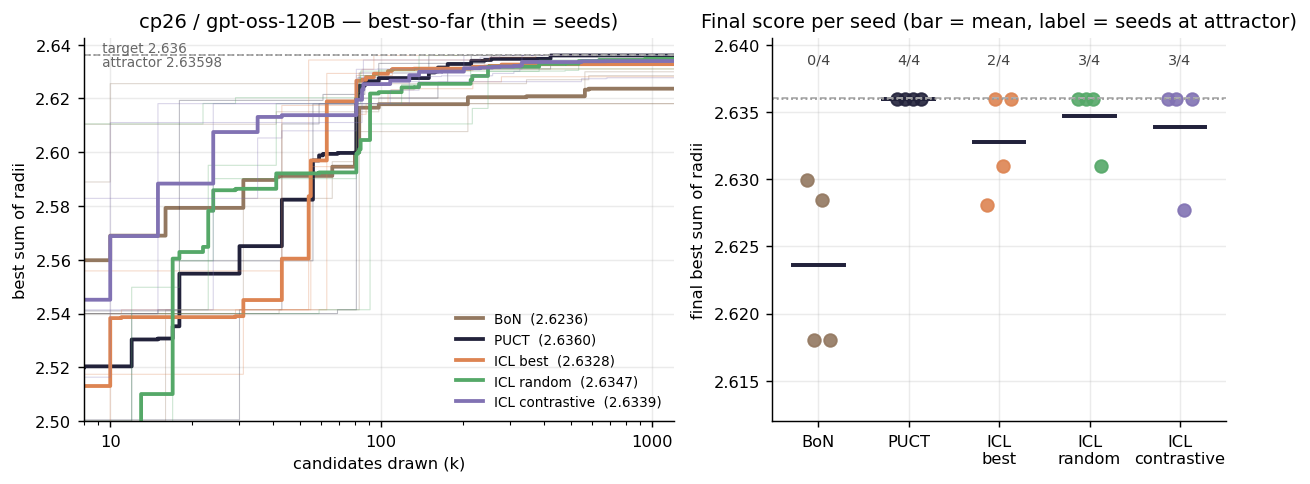

In [4]:
CP, MODEL = "circle_packing_26", "gpt-oss-120B"
ARMS_CP = ["BoN", "PUCT", "ICL best", "ICL random", "ICL contrastive"]
CV = {a: curves(CP, MODEL, a) for a in ARMS_CP}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})

for a in ARMS_CP:
    for c in CV[a].values():
        axL.step(np.arange(1, len(c) + 1), c, where="post", lw=.6, color=CARM[a], alpha=.30)
    m = mean_curve(CV[a])
    axL.step(np.arange(1, BUDGET + 1), m, where="post", lw=2.1, color=CARM[a],
             label=f"{a}  ({m[-1]:.4f})")
axL.axhline(TARGET[CP], ls="--", lw=1, color=CREF)
axL.text(9, TARGET[CP], f" target {TARGET[CP]}", va="bottom", fontsize=7.5, color="#666")
axL.axhline(ATTRACTOR, ls=":", lw=1, color="#999")
axL.text(9, ATTRACTOR, f" attractor {ATTRACTOR:.5f}", va="top", fontsize=7.5, color="#666")
axL.set(xscale="log", xlim=(8, BUDGET), ylim=(2.50, 2.6425), xlabel="candidates drawn (k)",
        ylabel="best sum of radii", title="cp26 / gpt-oss-120B — best-so-far (thin = seeds)")
axL.xaxis.set_major_formatter(ScalarFormatter())
axL.legend(fontsize=7.5, loc="lower right")

# final value per seed, and how many seeds reach the attractor
for i, a in enumerate(ARMS_CP):
    f = np.array([c[-1] for c in CV[a].values()])
    axR.plot(np.full(len(f), i) + np.linspace(-.13, .13, len(f)), f, "o", ms=7,
             color=CARM[a], alpha=.9)
    axR.plot([i - .28, i + .28], [f.mean()] * 2, lw=2.2, color=CMEAN)
    axR.text(i, 2.6386, f"{(f > ATTRACTOR - 1e-6).sum()}/{len(f)}", ha="center", fontsize=8,
             color="#444")
axR.axhline(TARGET[CP], ls="--", lw=1, color=CREF)
axR.axhline(ATTRACTOR, ls=":", lw=1, color="#999")
axR.set(xticks=range(len(ARMS_CP)), xticklabels=[a.replace("ICL ", "ICL\n") for a in ARMS_CP],
        ylim=(2.612, 2.6405), ylabel="final best sum of radii",
        title="Final score per seed (bar = mean, label = seeds at attractor)")
fig.savefig("mf_cp26_arms.png", dpi=200, bbox_inches="tight")

tab = pd.DataFrame({a: {"mean final": np.mean([c[-1] for c in CV[a].values()]),
                        "sd": np.std([c[-1] for c in CV[a].values()], ddof=1),
                        "seeds at attractor": f"{sum(c[-1] > ATTRACTOR - 1e-6 for c in CV[a].values())}/{len(CV[a])}"}
                    for a in ARMS_CP}).T
print(tab.to_string(float_format=lambda v: f"{v:.5f}"))

**Finding 1.** Ranked by mean final score: **BoN 2.62363** (0/4 seeds reach the attractor) <
**ICL best 2.63275** (2/4) < **ICL contrastive 2.63391** (3/4) < **ICL random 2.63473** (3/4) <
**PUCT 2.63598** (4/4, seed sd 6e-13).

Two different claims, with different amounts of support. **Search matters a lot:** every PUCT-based arm
beats Best-of-N, which never once reaches 2.63 in 4,800 candidates — a gap of 0.0124, comfortably above
the 0.0106 that 4 seeds can resolve (§3). **Adding past solutions on top of PUCT does not help here:**
the PUCT-to-ICL gaps are 0.0013–0.0032, *below* that threshold, so the right reading is "no measurable
gain", not "context hurts".

The sharper signal is reliability rather than the mean: **4/4 seeds at the attractor for PUCT against
2–3/4 for the ICL arms.** A count of successes does not suffer from the zero-variance problem the mean
has here.

## 2. cp26 is saturated — so the question is *which arm converges faster*

Twelve of the twenty gpt-oss runs end at exactly 2.6359830849, agreeing to ~10 digits. Final score is
therefore a near-degenerate statistic, and the question worth asking is **how fast each arm closes the
gap**.

Two views of exactly that. On the left, the distance still to go (attractor − best-so-far) on a log
axis: **lower is closer, and a steeper line is converging faster**. On the right, the same thing as a
race — **what share of an arm's seeds have reached the attractor by candidate k**. Together they
separate "gets close quickly" from "actually finishes", which turn out to be different arms.

median remaining gap to the attractor, and when seeds arrive
            arm gap@k=80 gap@k=160 gap@k=320 gap@k=640 gap@k=1200 k to attractor
            BoN   0.0194    0.0168    0.0168    0.0127     0.0127        — (0/4)
           PUCT   0.0180    0.0040    0.0001    0.0001     0.0001      235 (4/4)
       ICL best   0.0126    0.0037    0.0028    0.0026     0.0026      248 (2/4)
     ICL random   0.0319    0.0083    0.0054    0.0009     0.0001      877 (3/4)
ICL contrastive   0.0214    0.0064    0.0030    0.0001     0.0001      274 (3/4)

every seed's arrival at the attractor (k), sorted — the right panel as numbers
  BoN               none  + 4 never
  PUCT              [150, 215, 255, 422]  (all 4)
  ICL best          [122, 374]  + 2 never
  ICL random        [138, 877, 941]  + 1 never
  ICL contrastive   [202, 274, 417]  + 1 never

for reference — median k to first reach each lower threshold (over the seeds that get there)
            arm       2.60       2.62       2.63  attract

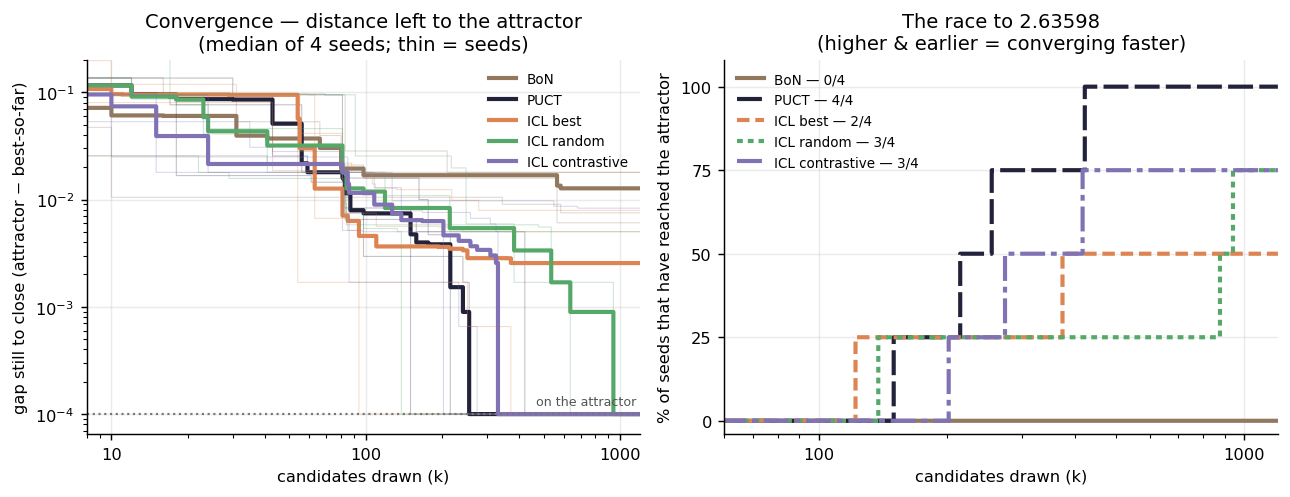

In [5]:
THR = [2.60, 2.62, 2.63, ATTRACTOR - 1e-6]
THR_LAB = ["2.60", "2.62", "2.63", "attractor"]

def k_to(c, t):
    hit = np.nonzero(c >= t)[0]
    return int(hit[0] + 1) if hit.size else None

FLOOR = 1e-4          # a run sitting on the attractor is drawn on this line, so log-y works
KS = np.arange(1, BUDGET + 1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.0, 3.9))

# LEFT: how much of the gap to the attractor is left. Lower = closer; steeper = converging faster.
for a in ARMS_CP:
    gaps = np.array([np.maximum(ATTRACTOR - pad(c), FLOOR) for c in CV[a].values()])
    for g in gaps:
        axL.step(KS, g, where="post", lw=.6, color=CARM[a], alpha=.28)
    axL.step(KS, np.median(gaps, axis=0), where="post", lw=2.3, color=CARM[a], label=a)
axL.axhline(FLOOR, ls=":", lw=1.2, color="#777")
axL.text(BUDGET, FLOOR * 1.2, "on the attractor ", ha="right", fontsize=7, color="#555")
axL.set(xscale="log", yscale="log", xlim=(8, BUDGET), ylim=(FLOOR * .65, .2),
        xlabel="candidates drawn (k)", ylabel="gap still to close (attractor − best-so-far)",
        title="Convergence — distance left to the attractor\n(median of 4 seeds; thin = seeds)")
axL.xaxis.set_major_formatter(ScalarFormatter())
axL.legend(fontsize=7.5, loc="upper right")

# RIGHT: the same question as a race -- what share of seeds have arrived by candidate k? Arms are given
# distinct dash patterns because with 4 seeds the curves share the same 0/25/50/75/100 levels and would
# otherwise hide each other where they coincide.
DASH = ["-", (0, (6, 1.5)), (0, (3, 1.4)), (0, (1.4, 1.2)), (0, (6, 1.4, 1.4, 1.4))]
for a, ds in zip(ARMS_CP, DASH):
    ks = [k_to(c, ATTRACTOR - 1e-6) for c in CV[a].values()]
    frac = np.zeros(BUDGET)
    for kk in ks:
        if kk:
            frac[kk - 1:] += 1
    frac = 100 * frac / len(ks)
    axR.step(KS, frac, where="post", lw=2.3, ls=ds, color=CARM[a],
             label=f"{a} — {sum(1 for k in ks if k)}/{len(ks)}")
axR.set(xscale="log", xlim=(60, BUDGET), ylim=(-4, 108), yticks=[0, 25, 50, 75, 100],
        xlabel="candidates drawn (k)", ylabel="% of seeds that have reached the attractor",
        title="The race to 2.63598\n(higher & earlier = converging faster)")
axR.xaxis.set_major_formatter(ScalarFormatter())
axR.legend(fontsize=7.5, loc="upper left")
fig.savefig("mf_cp26_speed.png", dpi=200, bbox_inches="tight")

auc = {a: np.array([pad(c).mean() for c in CV[a].values()]) for a in ARMS_CP}
rows = []
for a in ARMS_CP:
    gaps = np.array([np.maximum(ATTRACTOR - pad(c), FLOOR) for c in CV[a].values()])
    r = {"arm": a}
    for kk in (80, 160, 320, 640, 1200):
        r[f"gap@k={kk}"] = f"{np.median(gaps[:, kk - 1]):.4f}"
    ks = [k_to(c, ATTRACTOR - 1e-6) for c in CV[a].values()]
    got = [k for k in ks if k]
    r["k to attractor"] = f"{int(np.median(got))} ({len(got)}/{len(ks)})" if got else f"— (0/{len(ks)})"
    rows.append(r)
print("median remaining gap to the attractor, and when seeds arrive")
print(pd.DataFrame(rows).to_string(index=False))
print("\nevery seed's arrival at the attractor (k), sorted — the right panel as numbers")
for a in ARMS_CP:
    ks = sorted(k for k in (k_to(c, ATTRACTOR - 1e-6) for c in CV[a].values()) if k)
    miss = 4 - len(ks)
    print(f"  {a:<17} {ks if ks else 'none'}" + (f"  + {miss} never" if miss else "  (all 4)"))
print("\nfor reference — median k to first reach each lower threshold (over the seeds that get there)")
ref = []
for a in ARMS_CP:
    r = {"arm": a}
    for t, lab in zip(THR, THR_LAB):
        got = [k for k in (k_to(c, t) for c in CV[a].values()) if k]
        r[lab] = f"{int(np.median(got)):>4} ({len(got)}/4)" if got else "   — (0/4)"
    ref.append(r)
print(pd.DataFrame(ref).to_string(index=False))

**Finding 2 — only `best` converges faster early; PUCT overtakes by k≈160 and is the only arm that
reliably finishes.**

Reading the median remaining gap down the table:

| k | 80 | 160 | 320 | 1200 |
|---|---|---|---|---|
| **ICL best** | **0.0126** | **0.0037** | 0.0028 | 0.0026 |
| **PUCT** | 0.0180 | 0.0040 | **0.0001** | **0.0001** |
| ICL contrastive | 0.0214 | 0.0064 | 0.0030 | 0.0001 |
| ICL random | 0.0319 | 0.0083 | 0.0054 | 0.0001 |
| BoN | 0.0194 | 0.0168 | 0.0168 | 0.0127 |

* **"Context converges faster" is only true of `best`.** At k=80 it has closed a third more of the gap
  than PUCT (0.0126 vs 0.0180). `contrastive` (0.0214) and `random` (0.0319) are *behind* PUCT — and
  `random` is behind even Best-of-N. Which past solutions you show matters more than whether you show
  any: the top-scoring programs are worth copying, a uniform sample of the buffer is not.
* **The crossover is around k=160**, where `best` and PUCT are level (0.0037 vs 0.0040). After that
  PUCT alone keeps moving: it is at the floor by k=320 while every ICL arm stalls at 0.0026–0.0054.
* **The race panel is the cleanest statement of it.** Arrival candidates per seed:
  PUCT **[150, 215, 255, 422] — all four**; `contrastive` [202, 274, 417] + 1 never;
  `random` [138, 877, 941] + 1 never; `best` [122, 374] + **2 never**. So `best` gets a seed there
  first (k=122) and then loses half its seeds entirely — the fast-early / unreliable-late pattern in
  one line. PUCT is the only arm with no stragglers.
* **BoN never enters the race** — 0/4 seeds, gap flat at 0.0127 from k≈600.

So: **a good context block buys a head start worth ~0.005 of score over the first ~150 candidates;
PUCT buys the endgame.** Both effects are smaller than the 0.0106 the next section shows 4 seeds can
actually resolve, so treat the ordering as a direction to test, not a measurement.

## 3. Seed variability: cp26 cannot resolve these arms

How large a true difference would have to be before 4 seeds could see it, set against the size of the
gaps we are actually trying to call.

pooled seed sd 0.0045   SE over 4 seeds 0.0022   smallest detectable 2-arm gap 0.0106

all 10 pairwise comparisons of mean final score:
  BoN vs PUCT                0.0124   RESOLVED
  BoN vs random              0.0111   RESOLVED
  BoN vs contrastive         0.0103   not resolved
  BoN vs best                0.0091   not resolved
  PUCT vs best               0.0032   not resolved
  PUCT vs contrastive        0.0021   not resolved
  best vs random             0.0020   not resolved
  PUCT vs random             0.0013   not resolved
  best vs contrastive        0.0012   not resolved
  random vs contrastive      0.0008   not resolved
PUCT mean 2.635983 vs target 2.636: 1.69e-05 short — PUCT is at the ceiling of this problem
PUCT final sd is 5.8e-13 — all 4 seeds land on the same 10 digits

                 final CV %  k-to-2.63 CV %  AUC CV %
BoN                    0.25             NaN      0.28
PUCT                   0.00           23.01      0.08
ICL best               0.15           33.

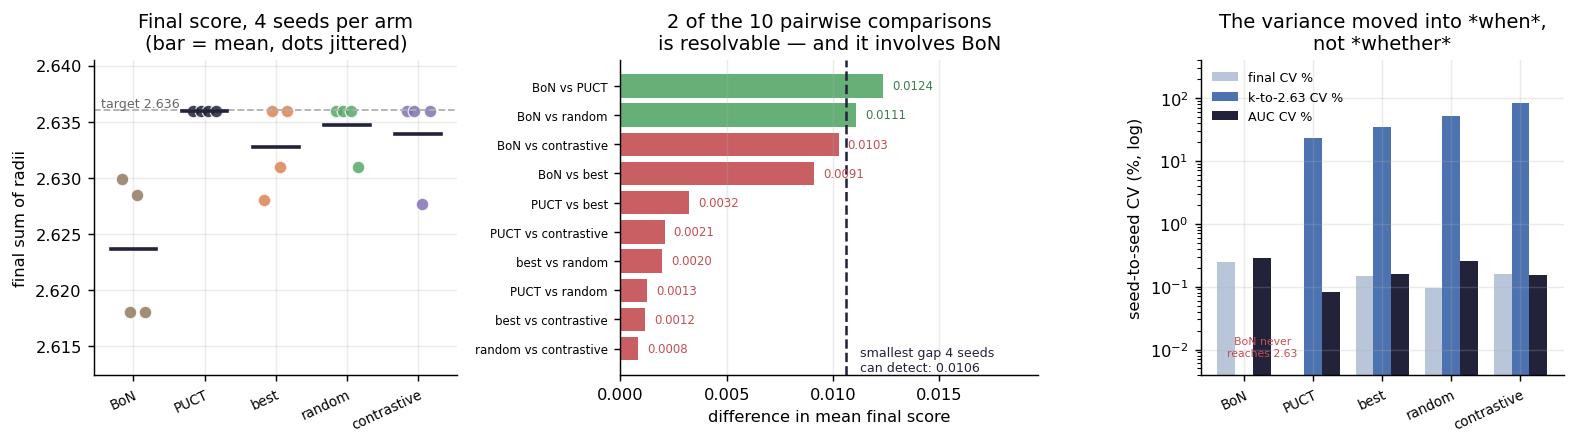

In [6]:
fin = {a: np.array([c[-1] for c in CV[a].values()]) for a in ARMS_CP}
pool_sd = np.sqrt(np.mean([f.var(ddof=1) for a, f in fin.items() if f.std() > 1e-9]))
se = pool_sd / np.sqrt(4)
MDE = 3.35 * se * np.sqrt(2)     # (t_.025 + t_.20) at df=6; normality approximate

gap_puct_bon = fin["PUCT"].mean() - fin["BoN"].mean()
gap_puct_icl = fin["PUCT"].mean() - max(fin[a].mean() for a in ARMS_CP if a.startswith("ICL"))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12.2, 3.5),
                                    gridspec_kw={"width_ratios": [1, 1.15, 1]})

# (1) the raw spread, with jitter so seeds landing on identical values stay visible
for i, a in enumerate(ARMS_CP):
    jit = np.linspace(-.16, .16, len(fin[a]))
    ax1.plot(i + jit, fin[a], "o", ms=7, color=CARM[a], alpha=.85, mec="white", mew=.7)
    ax1.plot([i - .32, i + .32], [fin[a].mean()] * 2, lw=2, color=CMEAN, zorder=3)
ax1.axhline(TARGET[CP], ls="--", lw=1, color=CREF)
ax1.text(-.45, TARGET[CP], f"target {TARGET[CP]}", fontsize=7, color="#666", va="bottom")
ax1.set(xlim=(-.55, 4.55), ylim=(2.6125, 2.6405), xticks=range(len(ARMS_CP)),
        xticklabels=[a.replace("ICL ", "") for a in ARMS_CP], ylabel="final sum of radii",
        title="Final score, 4 seeds per arm\n(bar = mean, dots jittered)")
ax1.tick_params(axis="x", labelsize=7.5)
plt.setp(ax1.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")

# (2) every pairwise gap against the smallest one 4 seeds could detect
pairs = [(x, y) for i, x in enumerate(ARMS_CP) for y in ARMS_CP[i + 1:]]
G = sorted(((abs(fin[x].mean() - fin[y].mean()), f"{x.replace('ICL ', '')} vs {y.replace('ICL ', '')}")
            for x, y in pairs), reverse=True)
ax2.barh(range(len(G)), [g for g, _ in G],
         color=["#55A868" if g > MDE else "#C44E52" for g, _ in G], alpha=.9)
ax2.axvline(MDE, color=CMEAN, ls="--", lw=1.4)
ax2.text(MDE * 1.06, len(G) - .6, f"smallest gap 4 seeds\ncan detect: {MDE:.4f}",
         fontsize=7, color=CMEAN, va="center")
for i, (g, _) in enumerate(G):
    ax2.text(g + MDE * .04, i, f"{g:.4f}", va="center", fontsize=6.5,
             color="#3E7B4F" if g > MDE else "#C44E52")
n_res = sum(1 for g, _ in G if g > MDE)
ax2.set(yticks=range(len(G)), yticklabels=[l for _, l in G], xlim=(0, MDE * 1.85),
        xticks=np.arange(0, MDE * 1.85, .005),
        xlabel="difference in mean final score",
        title=f"{n_res} of the {len(G)} pairwise comparisons\nis resolvable — and it involves BoN")
ax2.tick_params(axis="y", labelsize=6.5)
ax2.grid(axis="y", visible=False)
ax2.invert_yaxis()

# (3) where the variance actually lives
stats = {}
for a in ARMS_CP:
    got = [k for k in (k_to(c, 2.63) for c in CV[a].values()) if k]
    stats[a] = {"final CV %": 100 * fin[a].std(ddof=1) / fin[a].mean(),
                "k-to-2.63 CV %": 100 * np.std(got, ddof=1) / np.mean(got) if len(got) > 1 else np.nan,
                "AUC CV %": 100 * auc[a].std(ddof=1) / auc[a].mean()}
S = pd.DataFrame(stats).T
x = np.arange(len(ARMS_CP)); w = .26
for i, col in enumerate(S.columns):
    ax3.bar(x + (i - 1) * w, S[col].fillna(0), w, label=col,
            color=["#B9C6D9", "#4C72B0", "#22223B"][i])
ax3.text(0 + w, .008, "BoN never\nreaches 2.63", ha="center", fontsize=6, color="#C44E52")
ax3.set(xticks=x, xticklabels=[a.replace("ICL ", "") for a in ARMS_CP], yscale="log",
        ylim=(.004, 400), ylabel="seed-to-seed CV (%, log)",
        title="The variance moved into *when*,\nnot *whether*")
ax3.tick_params(axis="x", labelsize=7.5)
plt.setp(ax3.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")
ax3.legend(fontsize=7, loc="upper left")
fig.savefig("mf_cp26_noise.png", dpi=200, bbox_inches="tight")

print(f"pooled seed sd {pool_sd:.4f}   SE over 4 seeds {se:.4f}   "
      f"smallest detectable 2-arm gap {MDE:.4f}")
print(f"\nall {len(G)} pairwise comparisons of mean final score:")
for g, lab in G:
    print(f"  {lab:<26} {g:.4f}   {'RESOLVED' if g > MDE else 'not resolved'}")
print(f"PUCT mean {fin['PUCT'].mean():.6f} vs target {TARGET[CP]}: "
      f"{TARGET[CP] - fin['PUCT'].mean():.2e} short — PUCT is at the ceiling of this problem")
print(f"PUCT final sd is {fin['PUCT'].std(ddof=1):.1e} — all 4 seeds land on the same 10 digits\n")
print(S.to_string(float_format=lambda v: f"{v:6.2f}"))

**Finding 3 — of the ten pairwise comparisons, 4 seeds resolve two, and both are "beat Best-of-N".**

The pooled seed sd is 0.0045, so a two-arm difference needs about **0.0106** before 4 seeds can call
it. Against that yardstick (middle panel):

* **BoN vs PUCT (0.0124)** and **BoN vs ICL random (0.0111)** clear it. "Search beats no search" is a
  real result. BoN vs contrastive (0.0103) and BoN vs best (0.0091) *just miss*, which is a warning in
  itself — the headline claim is one seed away from being unsupported.
* **Every PUCT-vs-ICL and ICL-vs-ICL gap is 0.0008–0.0032**, three to thirteen times *below* the
  threshold. So section 1's ordering among the four search arms carries no statistical weight at all.
  What is *not* inside the noise is the reliability gap (4/4 vs 2–3/4 seeds at the attractor), because
  a count of successes does not have the mean's zero-variance problem.

And there is nowhere left to grow: PUCT's mean is **1.7e-5 short of the 2.636 target the prompt asks it
to beat**, with a seed sd of 6e-13 — all four seeds agree to ten digits.

The right-hand panel shows where the variance went. Final-score CV is 0.00–0.25%; **k-to-threshold CV
is 23–82%**. It did not disappear, it moved into *when* an arm gets there. So on cp26 report
time-to-threshold — and expect to need more than 4 seeds even then. The conclusion to carry forward:
**cp26 cannot rank these arms**, which makes ac1 (section 7) the load-bearing result.

## 4. Eval failures over generations — the symptom

Every candidate's outcome, per generation. Best-of-N has no generations, so its 1,200 candidates are
cut into the same 80-candidate blocks (`block = (k-1)//80`); for the PUCT/ICL arms `block` *is* the
generation.

            arm  seeds  candidates  valid eval_timeout process_crash invalid_result no_code first_block_valid last_block_valid
            BoN      4        4800  69.4%         0.5%         15.0%          15.0%    0.1%               68%              69%
           PUCT      4        4800  32.0%        52.7%         10.6%           4.7%    0.0%               71%              24%
       ICL best      4        4800  36.8%        52.7%          8.3%           2.1%    0.0%               72%              15%
     ICL random      4        4800  46.9%        43.2%          7.2%           2.7%    0.0%               68%              31%
ICL contrastive      4        4800  37.0%        55.6%          5.5%           1.9%    0.1%               72%              24%


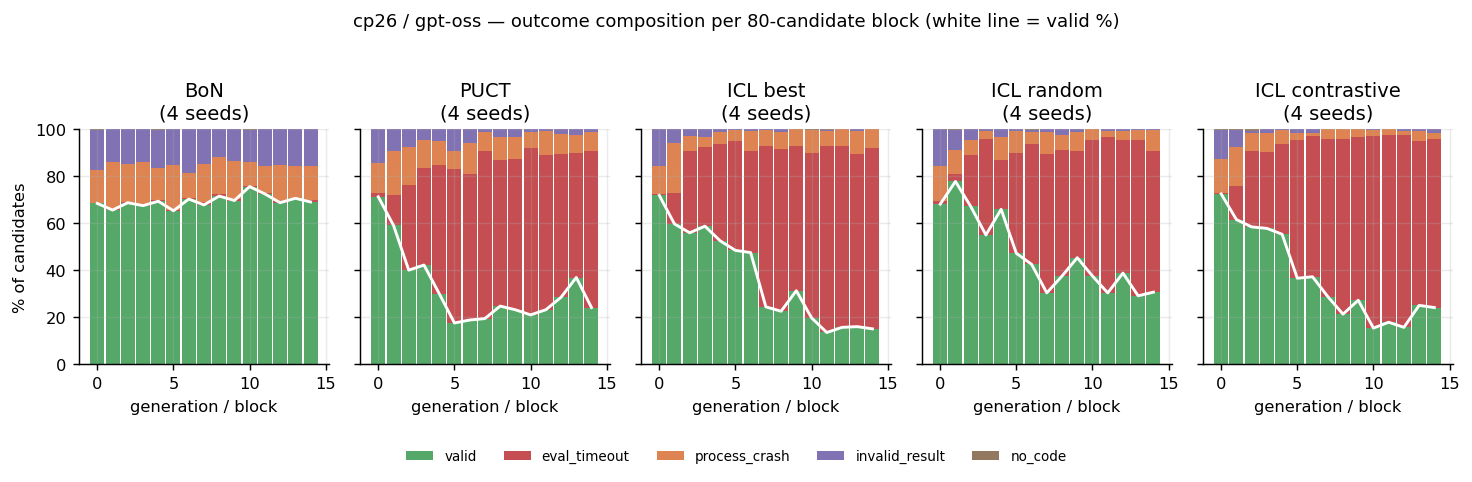

In [7]:
def outcome_matrix(problem, model, arm, n_context=None):
    # (blocks x outcome) counts summed over seeds, plus how many runs contributed.
    runs = arm_runs(problem, model, arm, n_context)
    m = collections.Counter()
    for _, d in runs:
        for (b, o), n in d.groupby(["block", "outcome"]).size().items():
            m[(b, o)] += n
    nb = 1 + max(b for b, _ in m)
    M = pd.DataFrame(0, index=range(nb), columns=FAIL_ORDER)
    for (b, o), n in m.items():
        if o in M.columns:
            M.loc[b, o] = n
    return M, len(runs)

fig, axes = plt.subplots(1, 5, figsize=(11.4, 3.1), sharey=True)
for ax, a in zip(axes, ARMS_CP):
    M, nr = outcome_matrix(CP, MODEL, a)
    tot = M.sum(axis=1).replace(0, np.nan)
    bot = np.zeros(len(M))
    for o in FAIL_ORDER:
        v = (100 * M[o] / tot).fillna(0).values
        ax.bar(M.index, v, bottom=bot, width=.92, color=CFAIL[o])
        bot += v
    ax.plot(M.index, 100 * M["valid"] / tot, color="white", lw=1.6)
    ax.set(title=f"{a}\n({nr} seeds)", xlabel="generation / block", ylim=(0, 100))
axes[0].set_ylabel("% of candidates")
fig.legend(handles=[Patch(fc=CFAIL[o], label=o) for o in FAIL_ORDER], fontsize=7.5, ncol=5,
           loc="lower center", bbox_to_anchor=(.5, -.11))
fig.suptitle("cp26 / gpt-oss — outcome composition per 80-candidate block "
             "(white line = valid %)", y=1.04, fontsize=10)
fig.savefig("mf_cp26_failures.png", dpi=200, bbox_inches="tight")

rows = []
for a in ARMS_CP:
    M, nr = outcome_matrix(CP, MODEL, a)
    tot = M.values.sum()
    rows.append(dict(arm=a, seeds=nr, candidates=tot,
                     **{o: f"{100 * M[o].sum() / tot:5.1f}%" for o in FAIL_ORDER},
                     first_block_valid=f"{100 * M.loc[0, 'valid'] / M.loc[0].sum():.0f}%",
                     last_block_valid=f"{100 * M.iloc[-1]['valid'] / M.iloc[-1].sum():.0f}%"))
print(pd.DataFrame(rows).to_string(index=False))

**The symptom, stated precisely.** In the four PUCT-based arms the valid fraction falls from **68–72%
in generation 0 to 15–31% by generation 14**, and essentially all of the loss is **`eval_timeout`**:
43–56% of all candidates over the whole run. `process_crash` and `invalid_result` *shrink* over the
same span (15% → 2–5% combined) — the model is not writing worse code, it is writing slower code.

Best-of-N, on the same box in the same hours, shows **none of this**: 68% valid in the first block,
69% in the last, with `eval_timeout` at 0.5% overall.

One detail worth noting for later: **`ICL random` is the mildest case** — 43.2% timeouts and 46.9%
valid against 52.7–55.6% and 32–37% for the others. Showing the model a random sample of past
solutions rather than the best ones puts *cheaper* programs in front of it, so runtime inflates more
slowly (§5a: 315s final survivor median vs PUCT's 419s). Cheap is not the same as good, though — §2
shows `random` is also the *slowest* search arm to close the gap early.

## 5. Why the timeouts grow: the solutions get slower, not the machine

Four measurements. (a) and (b) are properties of the *programs*; (c) and (d) are properties of the
*machine*. Only the first pair moves.

median eval seconds of the SURVIVORS, first block -> last block:
  BoN                   1.1s ->     0.9s   (    1x)
  PUCT                  1.3s ->   419.3s   (  332x)
  ICL best              2.8s ->   373.0s   (  135x)
  ICL random            1.6s ->   315.4s   (  194x)
  ICL contrastive       2.8s ->   413.1s   (  147x)

rank corr(eval seconds, score) over 7,326 valid candidates = 0.55
P(score >= 2.63) by eval-time bin:  0-1s 0.0% (n=183)   1-10s 1.1% (n=990)   10-100s 10.0% (n=1690)   100-300s 25.4% (n=2009)   300-530s 46.4% (n=2366)

per-arm probes (each figure is the median over that arm's seeds):
            arm     host  valid_eval_med  timeout_pct  kill_overhead  queue_med
            BoN guadiana            0.95         0.54           5.31       0.01
           PUCT guadiana          135.99        52.71           5.48      11.68
       ICL best    vouga          259.07        52.71           6.64       0.32
     ICL random    vouga          157.43        43.17           6.61 

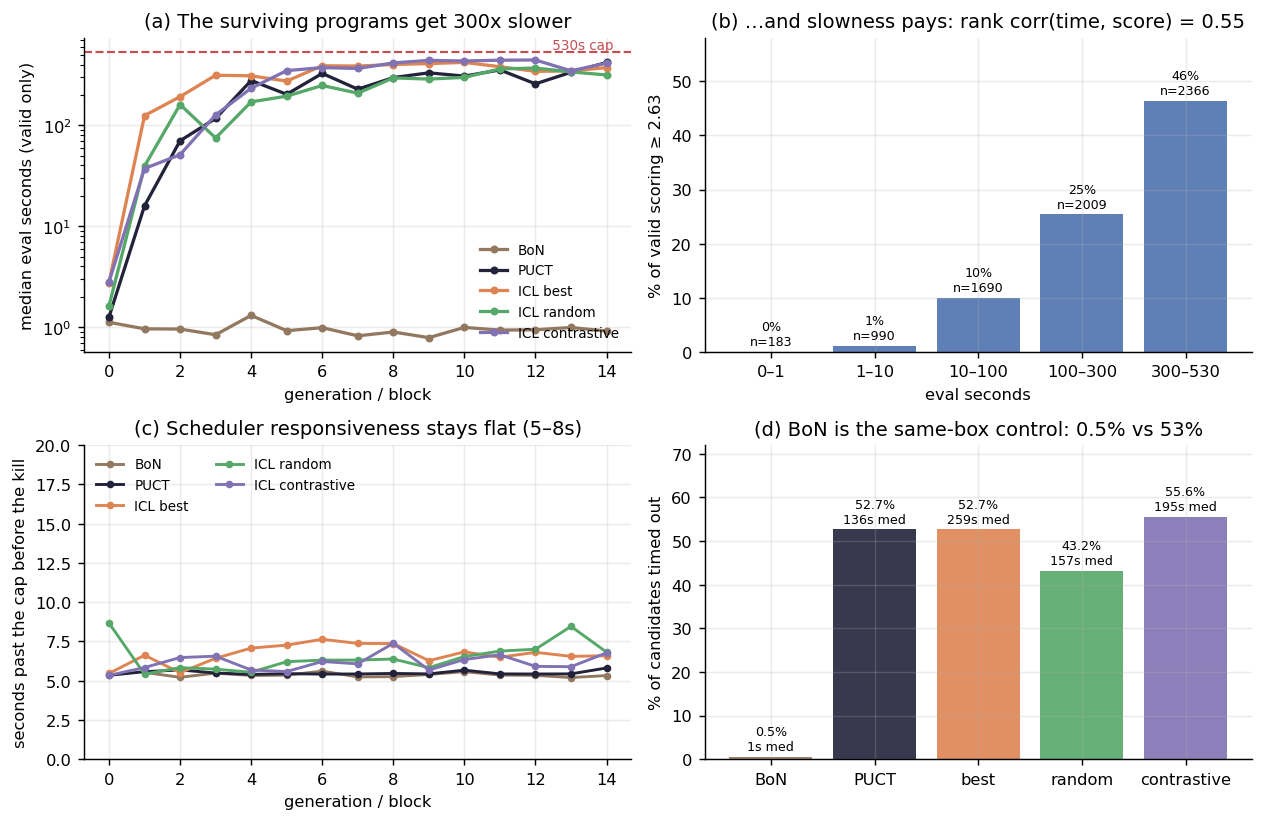

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(9.8, 6.4))
(a1, a2), (a3, a4) = axes

# ---- (a) eval time of the candidates that did NOT time out, per generation
drift = {}
for a in ARMS_CP:
    per = collections.defaultdict(list)
    for _, d in arm_runs(CP, MODEL, a):
        for b, sub in d[d.valid].groupby("block"):
            per[b].append(sub.eval_seconds.median())
    bs = sorted(per)
    y = [np.nanmedian(per[b]) for b in bs]
    drift[a] = (y[0], y[-1])
    a1.plot(bs, y, "-o", ms=3.4, lw=1.8, color=CARM[a], label=a)
a1.axhline(CAP[CP], ls="--", lw=1.2, color="#C44E52")
a1.text(14.2, CAP[CP], f" {CAP[CP]}s cap", ha="right", va="bottom", fontsize=7.5, color="#C44E52")
a1.set(yscale="log", xlabel="generation / block", ylabel="median eval seconds (valid only)",
       title="(a) The surviving programs get 300x slower")
a1.legend(fontsize=7.5, loc="lower right")

# ---- (b) is slow compute actually buying score?
E, S = [], []
for a in ["PUCT", "ICL best", "ICL random", "ICL contrastive"]:
    for _, d in arm_runs(CP, MODEL, a):
        v = d[d.valid & d.eval_seconds.notna()]
        E.append(v.eval_seconds.values); S.append(v.raw_score.values)
E, S = np.concatenate(E), np.concatenate(S)
rho = np.corrcoef(np.argsort(np.argsort(E)), np.argsort(np.argsort(S)))[0, 1]
BINS = [(0, 1), (1, 10), (10, 100), (100, 300), (300, CAP[CP])]
frac = [100 * (S[(E >= lo) & (E < hi)] >= 2.63).mean() for lo, hi in BINS]
nbin = [((E >= lo) & (E < hi)).sum() for lo, hi in BINS]
a2.bar(range(len(BINS)), frac, color="#4C72B0", alpha=.9)
for i, (f, n) in enumerate(zip(frac, nbin)):
    a2.text(i, f + 1.2, f"{f:.0f}%\nn={n}", ha="center", fontsize=7)
a2.set(xticks=range(len(BINS)), xticklabels=[f"{lo}–{hi}" for lo, hi in BINS], ylim=(0, 58),
       xlabel="eval seconds", ylabel="% of valid scoring ≥ 2.63",
       title=f"(b) …and slowness pays: rank corr(time, score) = {rho:.2f}")

# ---- (c) machine probes: they barely move
for a in ARMS_CP:
    per_k, per_q = collections.defaultdict(list), collections.defaultdict(list)
    for _, d in arm_runs(CP, MODEL, a):
        to = d[d.failure_type == "eval_timeout"]
        for b, sub in to.groupby("block"):
            per_k[b].append((sub.eval_seconds - CAP[CP]).median())
        for b, sub in d.groupby("block"):
            per_q[b].append(sub.queue_seconds.median())
    if per_k:
        bs = sorted(per_k)
        a3.plot(bs, [np.nanmedian(per_k[b]) for b in bs], "-o", ms=3.2, lw=1.6, color=CARM[a], label=a)
a3.set(xlabel="generation / block", ylabel="seconds past the cap before the kill",
       ylim=(0, 20), title="(c) Scheduler responsiveness stays flat (5–8s)")
a3.legend(fontsize=7.5, loc="upper left", ncol=2)

# ---- (d) BoN vs PUCT on the same box, same window
probe = []
for a in ARMS_CP:
    ev, to, ko, qq, host = [], 0, [], [], None
    for _, d in arm_runs(CP, MODEL, a):
        ev.append(d[d.valid].eval_seconds.median())
        to += int((d.failure_type == "eval_timeout").sum())
        ko.append((d[d.failure_type == "eval_timeout"].eval_seconds - CAP[CP]).median())
        qq.append(d.queue_seconds.median())
    n = sum(len(d) for _, d in arm_runs(CP, MODEL, a))
    probe.append(dict(arm=a, host=INV[(INV.problem == CP) & (INV.model == MODEL) & (INV.arm == a)].host.iloc[0],
                      valid_eval_med=np.median(ev), timeout_pct=100 * to / n,
                      kill_overhead=np.nanmedian(ko), queue_med=np.median(qq)))
P = pd.DataFrame(probe)
a4.bar(np.arange(len(P)), P.timeout_pct, color=[CARM[a] for a in P.arm], alpha=.9)
for i, r in P.iterrows():
    a4.text(i, r.timeout_pct + 1.5, f"{r.timeout_pct:.1f}%\n{r.valid_eval_med:.0f}s med", ha="center", fontsize=7)
a4.set(xticks=np.arange(len(P)), xticklabels=[a.replace("ICL ", "") for a in P.arm],
       ylabel="% of candidates timed out", ylim=(0, 72),
       title=f"(d) BoN is the same-box control: "
             f"{P[P.arm == 'BoN'].timeout_pct.iloc[0]:.1f}% vs {P[P.arm == 'PUCT'].timeout_pct.iloc[0]:.0f}%")
fig.savefig("mf_cp26_diagnosis.png", dpi=200, bbox_inches="tight")

print("median eval seconds of the SURVIVORS, first block -> last block:")
for a, (f, l) in drift.items():
    print(f"  {a:<17} {f:7.1f}s -> {l:7.1f}s   ({l / f:5.0f}x)")
print(f"\nrank corr(eval seconds, score) over {E.size:,} valid candidates = {rho:.2f}")
print("P(score >= 2.63) by eval-time bin:  " +
      "   ".join(f"{lo}-{hi}s {f:.1f}% (n={n})" for (lo, hi), f, n in zip(BINS, frac, nbin)))
print("\nper-arm probes (each figure is the median over that arm's seeds):")
print(P.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

**Finding 4 — on cp26 the growing timeouts are the solutions, not the machine.**

* (a) Among the candidates that **did not** time out, the median eval time rises from **1.3s in
  generation 0 to 419s by generation 14 — 332x** for PUCT (135–194x for the ICL arms), with p90
  pressed against the 530s cap. The programs themselves got two orders of magnitude more expensive.
* (b) That slowness is not waste. P(score ≥ 2.63) climbs **0% → 1% → 10% → 25% → 46%** across the
  eval-time bins, rank correlation **0.55**. Good packings genuinely need long numerical optimisation,
  so the cap **censors exactly the productive region** — it does not merely burn budget, it hides the
  best candidates from the buffer, corrupting PUCT's `Q(s)` and its rank prior `P(s)`. That is the
  same failure mode the Bosch investigation found (§9), arriving here for a different reason.
* (c) The machine probe stays flat. The time between the cap firing and the process dying is
  **5.3–6.6s for the whole run**, on both hosts; `queue_seconds` medians are 0.01–11.7s. Nothing here
  moved by more than ~1.3x while (a) moved 332x.
* (d) **The decisive control:** Best-of-N ran on the same `guadiana`, in the same hours, 4-wide, and
  its survivors' median eval went **1.1s → 0.9s — a factor of 1.0, no drift at all** — for a
  **0.54%** timeout rate against PUCT's **52.7%**. The only structural difference is that BoN's parent
  is always the seed, so nothing accumulates. Same box, same window, same problem, 100x the timeout
  rate: the box is not the variable.

**Mechanism.** PUCT selects parents by score. Longer-running programs score better (b). Children
inherit their parent's optimiser and the cheapest way to nudge a packing is more restarts and more
iterations. Nothing anywhere tells the model a time limit exists — the cp26 prompt never mentions one
— and eval cost is absent from the reward. So runtime inflates monotonically until the median program
hits the wall around generation 4–5, after which 50–75% of every generation is discarded. That is
also why best-so-far in section 1 flattens after generation ~5.

## 6. ac1 has the same symptom with the opposite cause — a 9% margin

On `ac1` the prompt *does* state a budget: the model is told its function has
`budget_s = 1000` seconds (`envs/ac_inequalities.py:259,275`) and the initial program is written as an
anytime loop, `deadline = time.time() + budget_s - 10`. The registry's hard kill is **1100s**
(`envs/registry.py:32`). So the intended runtime and the cap are 9% apart.

all ac1 valid evals: median 1004.4s   p10 33.1s   p90 1044.8s   n=14,516
share of valid evals inside [900, 1100]s: 79%
generations with a survivor-median below 1005s: 2 kills of 80 (median).  Above 1030s: 18 of 80.

the programs, not the box, set the runtime — survivors' median eval is ~1004s everywhere:
          generations  med_eval_s  killed_per_80
host                                            
cavado             45      1004.3            1.0
guadiana          110      1006.6            4.0
lima               30      1000.9            3.5
tamega              5      1000.0            3.0
zezere             30      1023.7           14.0


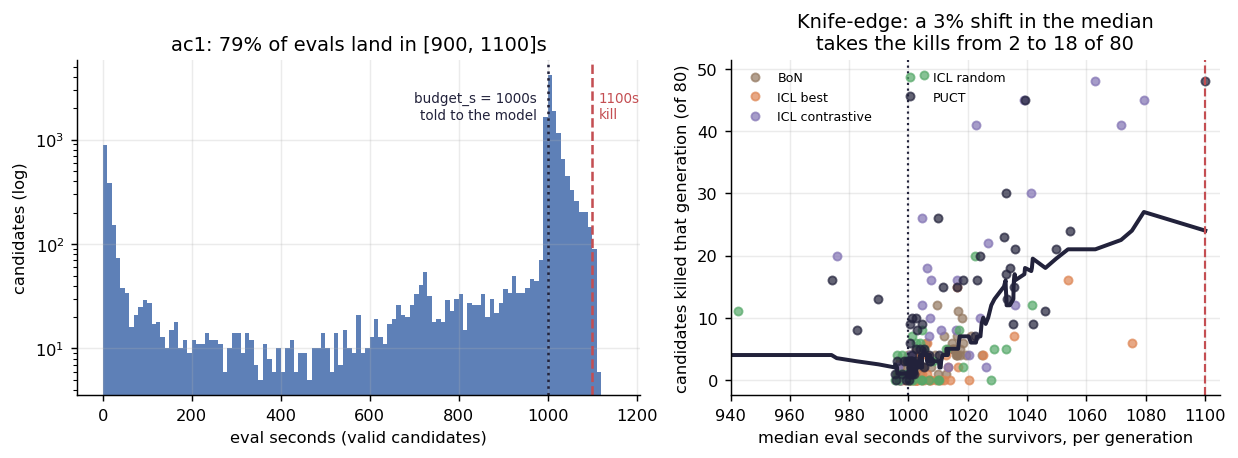

In [9]:
AC = "ac1"
AC_ARMS = [("PUCT", None), ("BoN", None), ("ICL best", 10), ("ICL random", 10),
           ("ICL contrastive", 10), ("ICL best", 5), ("ICL random", 5), ("ICL contrastive", 5)]
def ac_label(a, n):
    return a if n is None else f"{a} n{n}"

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1.15, 1]})

allv = np.concatenate([d[d.valid].eval_seconds.dropna().values
                       for a, n in AC_ARMS for _, d in arm_runs(AC, "gpt-oss-120B", a, n)])
axL.hist(allv, bins=np.linspace(0, 1150, 116), color="#4C72B0", alpha=.9)
axL.set(yscale="log", xlabel="eval seconds (valid candidates)", ylabel="candidates (log)",
        title=f"ac1: {100 * ((allv > 900) & (allv < CAP[AC])).mean():.0f}% of evals land in [900, 1100]s")
top = axL.get_ylim()[1]
axL.axvline(AC1_BUDGET_S, ls=":", lw=1.4, color="#22223B")
axL.text(AC1_BUDGET_S - 25, top * .5, f"budget_s = {AC1_BUDGET_S}s\ntold to the model",
         ha="right", va="top", fontsize=7.5, color="#22223B")
axL.axvline(CAP[AC], ls="--", lw=1.4, color="#C44E52")
axL.text(CAP[AC] + 15, top * .5, f"{CAP[AC]}s\nkill", va="top", fontsize=7.5, color="#C44E52")

# knife-edge: per generation, the survivors' median eval against how many were killed
pts = []
for r, d in runs_of(AC):
    for b, sub in d.groupby("block"):
        v = sub[sub.valid].eval_seconds.dropna()
        if len(v) >= 5:
            pts.append((v.median(), int((sub.failure_type == "eval_timeout").sum()), r.arm, r.host))
PT = pd.DataFrame(pts, columns=["med_eval", "killed", "arm", "host"])
for a, sub in PT.groupby("arm"):
    axR.plot(sub.med_eval, sub.killed, "o", ms=4.5, alpha=.7, color=CARM[a], label=a)
o = PT.sort_values("med_eval")
axR.plot(o.med_eval, o.killed.rolling(25, min_periods=8, center=True).median(), lw=2.2, color=CMEAN)
axR.axvline(AC1_BUDGET_S, ls=":", lw=1.2, color="#22223B")
axR.axvline(CAP[AC], ls="--", lw=1.2, color="#C44E52")
lo = PT[PT.med_eval < 1005].killed.median()
hi = PT[PT.med_eval > 1030].killed.median()
axR.set(xlim=(940, 1105), xlabel="median eval seconds of the survivors, per generation",
        ylabel="candidates killed that generation (of 80)",
        title=f"Knife-edge: a 3% shift in the median\ntakes the kills from {lo:.0f} to {hi:.0f} of 80")
axR.legend(fontsize=7, loc="upper left", ncol=2)
fig.savefig("mf_ac1_wall.png", dpi=200, bbox_inches="tight")

print(f"all ac1 valid evals: median {np.median(allv):.1f}s   p10 {np.percentile(allv, 10):.1f}s   "
      f"p90 {np.percentile(allv, 90):.1f}s   n={allv.size:,}")
print(f"share of valid evals inside [900, {CAP[AC]}]s: "
      f"{100 * ((allv > 900) & (allv < CAP[AC])).mean():.0f}%")
print(f"generations with a survivor-median below 1005s: {lo:.0f} kills of 80 (median).  "
      f"Above 1030s: {hi:.0f} of 80.")
print("\nthe programs, not the box, set the runtime — survivors' median eval is ~1004s everywhere:")
print(PT.groupby("host").agg(generations=("med_eval", "size"), med_eval_s=("med_eval", "median"),
                             killed_per_80=("killed", "median"))
        .to_string(float_format=lambda v: f"{v:.1f}"))

In [10]:
# per run: the survivors' median eval barely differs, but the kill count differs 25-fold -- and it
# tracks the host, not the arm. That is the signature of a margin that is too thin, not of an arm.
# Normalised per *candidate*, not per generation -- Best-of-N packs all 1,200 into one generation,
# so timeouts-per-generation is not a comparable unit across arms.
rows = []
for r, d in runs_of(AC):
    to = int((d.failure_type == "eval_timeout").sum())
    rows.append(dict(run=f"{r.arm} {r.n_ctx_label} s{r.seed}", host=r.host, gens=r.gens_done,
                     cands=len(d), valid_eval_med=d[d.valid].eval_seconds.median(),
                     valid_eval_p90=d[d.valid].eval_seconds.quantile(.9),
                     timeouts=to, timeout_pct=100 * to / len(d)))
AC_T = pd.DataFrame(rows).sort_values("timeout_pct")
print(AC_T.to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print("\nmedian timeout rate by host (same problem, same cap, different box):")
print(AC_T.groupby("host").timeout_pct.median().sort_values()
          .to_string(float_format=lambda v: f"{v:.1f}%"))
print(f"\nThe survivors' median eval spans only {AC_T.valid_eval_med.min():.0f}–"
      f"{AC_T.valid_eval_med.max():.0f}s ({100 * (AC_T.valid_eval_med.max() / AC_T.valid_eval_med.min() - 1):.0f}% "
      f"apart) — but the timeout rate spans {AC_T.timeout_pct.min():.1f}%–{AC_T.timeout_pct.max():.1f}%, "
      f"a {AC_T.timeout_pct.max() / max(AC_T.timeout_pct.min(), 1e-9):.0f}x range.")
print(f"p90 of the survivors is the tell: {AC_T.valid_eval_p90.min():.0f}–{AC_T.valid_eval_p90.max():.0f}s "
      f"against a {CAP[AC]}s cap — the runs with a p90 near the cap are the ones bleeding candidates.")

                    run     host  gens  cands  valid_eval_med  valid_eval_p90  timeouts  timeout_pct
        ICL best n=5 s1   cavado    15   1200          1002.9          1017.1         6          0.5
               BoN — s2 guadiana     1   1200           999.9          1016.9        26          2.2
               BoN — s3 guadiana     1   1200           999.0          1019.3        27          2.2
      ICL random n=5 s1   cavado    15   1200          1002.2          1035.3        34          2.8
       ICL best n=10 s1 guadiana    15   1200          1011.1          1059.7        37          3.1
       ICL best n=10 s3   tamega     2    160           999.4          1029.1         5          3.1
     ICL random n=10 s3   tamega     3    240           999.1          1022.3         8          3.3
               BoN — s4 guadiana     1   1200          1007.8          1035.1        45          3.8
              PUCT — s3     lima    15   1200          1002.7          1018.7        70    

**Finding 5 — ac1's timeouts are a scaffold margin bug, and here the machine *does* matter.**

**79% of all valid ac1 evals land in [900, 1100]s**, with a median of 1004s — and that median is
**1000–1024s on every one of the five hosts** (`cavado`, `tamega`, `lima`, `zezere`, `guadiana`), a 3%
spread. That cross-host constancy is the proof: the programs are self-budgeting to the 1000s they were
*told* about, not being slowed by any particular box. But it leaves only ~9% of headroom before the
1100s kill, so the entire population sits one small perturbation from the wall.

The consequence is that on ac1 the timeout *rate* is almost pure noise. Across runs it spans
**0.5% to 32.8% — a 66x range — while the survivor median moves 3%.** What predicts it is not the arm
but the **p90 of the survivors** (1017s → 1088s across runs): once the p90 crosses the cap, candidates
bleed. And that tracks the box: median timeout rate is 2.8% on `cavado`, 5.0% on `guadiana`, **17.8%
on `zezere`**.

Two clean demonstrations that this is load, not method:

* **Same arm, same host, same day:** the four ac1 Best-of-N runs all sit on `guadiana` and took
  26, 27, 45 and **95** timeouts. Nothing about the method differed.
* **Within one run:** in `ac1_gptoss/puct_s1` the survivor median drifts +4% (996s → 1046s) across
  generations and the kills go from **3 to 23 per generation**.

**So ac1 failure counts cannot be attributed to an arm at all**, and the fix is one line either way:
raise the cap to ~1.5x `budget_s`, or drop `budget_s` to ~700 and keep the 1100s cap. Note this also
means ac1's scores are pessimistic by an unknown amount for the unlucky runs — the same
near-best-candidate censoring as §9, so the ranking in §7 should be re-checked after the fix.

## 7. ac1: search buys nothing, and the best runs are ICL

ac1 minimises an upper bound (lower is better); target 1.5030. Nothing here is saturated: the runs
span 1.5064–1.5185, with no attractor anyone piles onto. **Caveat first: the ICL arms have one seed
per configuration**, so below they are drawn as individual lines against the 8-run PUCT/BoN band, and
the runs still in flight are dotted with a red ring.

multi-seed arms, full-budget runs only
  PUCT  n=4  mean 1.51515  sd 0.00109  best 1.51417
  BoN   n=4  mean 1.51543  sd 0.00254  best 1.51214

single-seed ICL runs, full budget (SUGGESTIVE ONLY — n=1 each)
  ICL best n10 s1          1.50643   (15 gens, guadiana)
  ICL best n5 s1           1.50952   (15 gens, cavado)
  ICL random n5 s1         1.51037   (15 gens, cavado)
  ICL contrastive n5 s1    1.51468   (15 gens, cavado)
  ICL random n10 s1        1.51631   (15 gens, guadiana)

still in flight
  ICL random n10 s2        1.51220   (2 gens so far, guadiana)
  ICL best n10 s2          1.51256   (5 gens so far, guadiana)
  ICL random n10 s3        1.51645   (3 gens so far, tamega)
  ICL contrastive n10 s1   1.51659   (13 gens so far, guadiana)
  ICL best n10 s3          1.51853   (2 gens so far, tamega)

best ICL run 1.50643 vs the whole PUCT/BoN spread 1.51214–1.51833


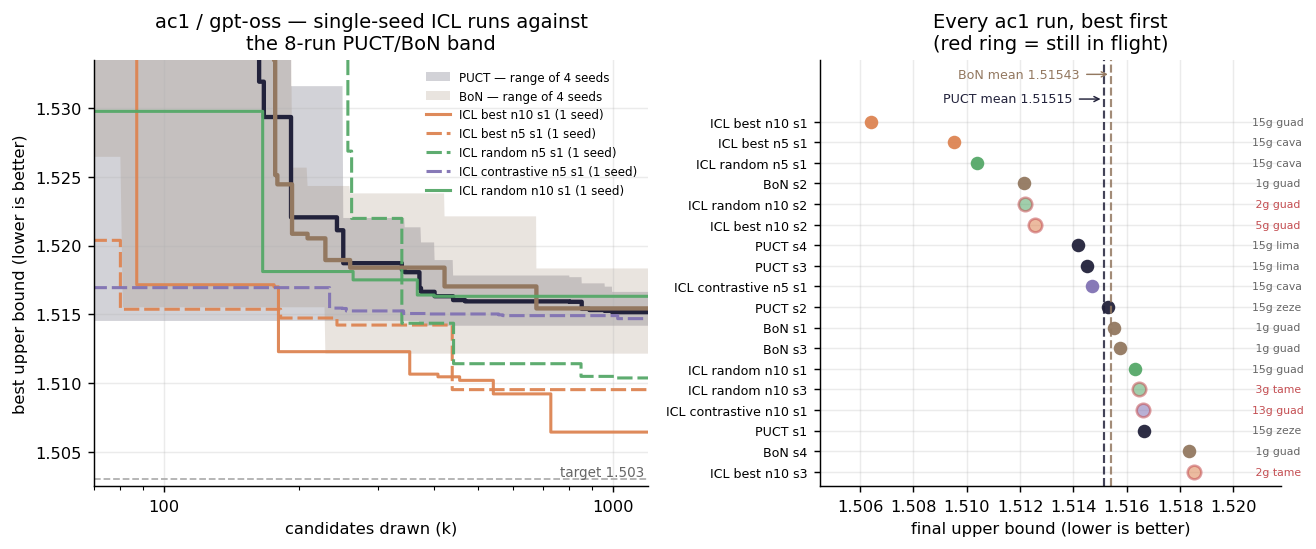

In [11]:
# One record per RUN (not per arm): with 1 seed on most ICL arms, an arm mean would be a mean of one,
# and the 2-generation partials would drag it. `done` marks a run that spent its full budget.
AC_RUNS = []
for r, d in runs_of(AC):
    c = best_so_far(np.where(d.valid, d.raw_score, np.nan), MAXIMIZE[AC])
    AC_RUNS.append(dict(arm=r.arm, n=r.n_context, seed=r.seed, host=r.host, gens=r.gens_done,
                        label=f"{r.arm}{'' if r.n_context == 0 else f' n{r.n_context}'} s{r.seed}",
                        done=r.candidates >= BUDGET * .9, final=c[-1], curve=c))
AC_RUNS = sorted(AC_RUNS, key=lambda x: x["final"])
DONE = [x for x in AC_RUNS if x["done"]]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.2, 4.3), gridspec_kw={"width_ratios": [1.2, 1]})

# LEFT: the 8 multi-seed search runs become a band; the single-seed ICL runs are drawn on top, so the
# question "does any ICL run leave the search band?" is answerable by eye.
for a in ("PUCT", "BoN"):
    M = np.array([pad(x["curve"]) for x in DONE if x["arm"] == a])
    axL.fill_between(KS, M.min(0), M.max(0), color=CARM[a], alpha=.20, lw=0,
                     label=f"{a} — range of {len(M)} seeds")
    axL.step(KS, M.mean(0), where="post", lw=2.4, color=CARM[a])
for x in DONE:                                    # n=10 solid, n=5 dashed (same colour per strategy)
    if x["arm"].startswith("ICL"):
        axL.step(np.arange(1, len(x["curve"]) + 1), x["curve"], where="post", lw=1.7,
                 color=CARM[x["arm"]], alpha=.95, ls="-" if x["n"] == 10 else (0, (5, 1.6)),
                 label=f"{x['label']} (1 seed)")
axL.axhline(TARGET[AC], ls="--", lw=1, color=CREF)
axL.text(BUDGET, TARGET[AC], f"target {TARGET[AC]} ", ha="right", va="bottom", fontsize=7.5, color="#666")
axL.set(xscale="log", xlim=(70, BUDGET), ylim=(1.5025, 1.5335), xlabel="candidates drawn (k)",
        ylabel="best upper bound (lower is better)",
        title="ac1 / gpt-oss — single-seed ICL runs against\nthe 8-run PUCT/BoN band")
axL.xaxis.set_major_formatter(ScalarFormatter())
axL.legend(fontsize=6.6, loc="upper right")

# RIGHT: every run, best first. In-flight runs get a red ring and their generation count.
for i, x in enumerate(AC_RUNS):
    axR.plot(x["final"], i, "o", ms=7.5, color=CARM[x["arm"]],
             mec="none" if x["done"] else "#C44E52", mew=1.4, alpha=.95 if x["done"] else .55)
    axR.text(1.5207, i, f"{x['gens']:>2}g {x['host'][:4]}", fontsize=6, va="center",
             color="#666" if x["done"] else "#C44E52")
for a, col, dy in (("PUCT", CARM["PUCT"], -1.1), ("BoN", CARM["BoN"], -2.3)):
    m = np.mean([x["final"] for x in DONE if x["arm"] == a])
    axR.axvline(m, color=col, ls="--", lw=1.2, alpha=.85)
    axR.annotate(f"{a} mean {m:.5f}", xy=(m, dy), xytext=(m - .0012, dy), fontsize=7, color=col,
                 ha="right", va="center",
                 arrowprops=dict(arrowstyle="->", lw=.8, color=col))
axR.set(yticks=range(len(AC_RUNS)), yticklabels=[x["label"] for x in AC_RUNS],
        xlim=(1.5045, 1.5218), ylim=(len(AC_RUNS) - .3, -3.0),
        xlabel="final upper bound (lower is better)",
        title="Every ac1 run, best first\n(red ring = still in flight)")
axR.tick_params(axis="y", labelsize=7)
fig.savefig("mf_ac1_arms.png", dpi=200, bbox_inches="tight")

print("multi-seed arms, full-budget runs only")
for a in ("PUCT", "BoN"):
    f = np.array([x["final"] for x in DONE if x["arm"] == a])
    print(f"  {a:<5} n={len(f)}  mean {f.mean():.5f}  sd {f.std(ddof=1):.5f}  best {f.min():.5f}")
print("\nsingle-seed ICL runs, full budget (SUGGESTIVE ONLY — n=1 each)")
for x in DONE:
    if x["arm"].startswith("ICL"):
        print(f"  {x['label']:<24} {x['final']:.5f}   ({x['gens']} gens, {x['host']})")
print("\nstill in flight")
for x in AC_RUNS:
    if not x["done"]:
        print(f"  {x['label']:<24} {x['final']:.5f}   ({x['gens']} gens so far, {x['host']})")
best_icl = min(x["final"] for x in DONE if x["arm"].startswith("ICL"))
worst_search = max(x["final"] for x in DONE if not x["arm"].startswith("ICL"))
print(f"\nbest ICL run {best_icl:.5f} vs the whole PUCT/BoN spread "
      f"{min(x['final'] for x in DONE if not x['arm'].startswith('ICL')):.5f}–{worst_search:.5f}")

**Finding 6 — on the problem that is *not* saturated, search buys nothing and the best runs are ICL.**

**The solid part of this, on 4 seeds each:** PUCT **1.51515 ± 0.00109** vs Best-of-N
**1.51543 ± 0.00254**. A gap of 0.0003 against a seed sd of 0.001–0.003, i.e. **PUCT ≈ BoN**. At 1,200
candidates, PUCT's parent selection buys *nothing at all* over independent sampling from the seed —
the exact opposite of cp26, where it was the only arm to reach the attractor. That comparison has
enough seeds to stand on.

**The suggestive part, n=1 per configuration.** Of the five full-budget ICL runs, **three beat every
one of the eight PUCT/BoN runs**: `n10 best` **1.50643**, `n05 best` **1.50952**, `n05 random`
**1.51037**, against a PUCT/BoN spread of 1.51214–1.51833. But the other two land *inside* that spread
(`n05 contrastive` 1.51468, `n10 random` 1.51631). So the ICL runs span **0.010 — nine times PUCT's
seed sd** — and with one seed per configuration there is no way to split "strategy effect" from "seed
luck". Two honest readings survive: the ceiling of the ICL arms is higher than anything search reached,
and ICL is far more variable. Both need 4 seeds before they can be quoted.

**`n05` vs `n10` gives no consistent answer** either: for `best` the larger context wins
(1.50643 vs 1.50952), for `random` the smaller does (1.51037 vs 1.51631). One seed each, and they ran
on different boxes with a 3x difference in timeout rate, so these are not clean replicates.

Why a reversal is *plausible* if it survives more seeds: cp26's space is a handful of memorised
closed-form constructions, so what matters is *finding* the attractor — a parent-selection job. ac1
asks for a search **procedure**, where seeing ten previous procedures and their scores is genuinely
informative and which parent you start from matters less. This is the one place in the campaign where
the arms could actually separate, and it is exactly where the seeds are missing.

## 8. What context costs under a fixed budget

Every arm generated 1,200 completions, so decode is matched by construction. Prefill is not.

tokens per candidate (mean over that arm's runs)
          problem               label  runs  prompt_pc  compl_pc  reason_share
circle_packing_26                 BoN     4      56.50  4,231.53          0.75
circle_packing_26      ICL random n10     4   1,113.83  3,747.42          0.27
circle_packing_26                PUCT     4     219.57  4,140.66          0.27
circle_packing_26 ICL contrastive n10     4   1,342.79  4,144.00          0.23
circle_packing_26        ICL best n10     4   1,839.29  4,252.73          0.22
              ac1                 BoN     4     125.69  3,835.67          0.59
              ac1      ICL random n10     3     960.02  4,597.80          0.46
              ac1                PUCT     4     242.63  4,295.59          0.34
              ac1        ICL best n10     3   1,276.94  4,006.42          0.33
              ac1  ICL contrastive n5     1     976.75  4,895.48          0.27
              ac1       ICL random n5     1     967.07  4,531.59          0.26
   

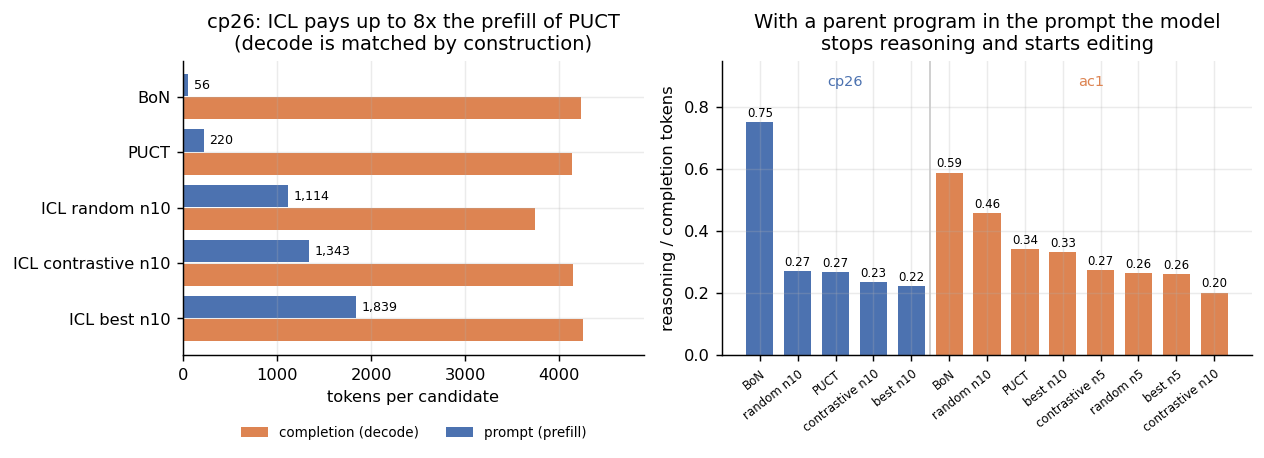

In [12]:
# Per *candidate*, so a 2-generation partial and a 15-generation run are on the same footing, and
# Best-of-N (one 1,200-candidate generation) is comparable to the rest.
gp = INV[INV.model == "gpt-oss-120B"].copy()
gp["label"] = gp.arm + np.where(gp.n_context > 0, " n" + gp.n_context.astype(str), "")
gp["prompt_pc"] = gp.prompt_tok / gp.candidates
gp["compl_pc"] = gp.compl_tok / gp.candidates
gp["reason_share"] = gp.reason_tok / gp.compl_tok
agg = (gp.groupby(["problem", "label"])
         .agg(runs=("run", "size"), prompt_pc=("prompt_pc", "mean"), compl_pc=("compl_pc", "mean"),
              reason_share=("reason_share", "mean"))
         .reset_index().sort_values(["problem", "prompt_pc"]))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.8, 3.6), gridspec_kw={"width_ratios": [1, 1.15]})
cp_agg = agg[agg.problem == CP]
y = np.arange(len(cp_agg))
axL.barh(y + .21, cp_agg.compl_pc, .40, color="#DD8452", label="completion (decode)")
axL.barh(y - .21, cp_agg.prompt_pc, .40, color="#4C72B0", label="prompt (prefill)")
for i, r in enumerate(cp_agg.itertuples()):
    axL.text(r.prompt_pc + 60, i - .21, f"{r.prompt_pc:,.0f}", va="center", fontsize=7)
base_pc = cp_agg[cp_agg.label == "PUCT"].prompt_pc.iloc[0]
axL.set(yticks=y, yticklabels=cp_agg.label, xlabel="tokens per candidate", xlim=(0, 4900),
        title=f"cp26: ICL pays up to {cp_agg.prompt_pc.max() / base_pc:.0f}x the prefill of PUCT\n"
              f"(decode is matched by construction)")
axL.legend(fontsize=7.5, loc="upper center", bbox_to_anchor=(.5, -.20), ncol=2)
axL.invert_yaxis()

agg = agg.sort_values(["problem", "reason_share"], ascending=[False, False])   # cp26 block first
xs = np.arange(len(agg))
axR.bar(xs, agg.reason_share, .72,
        color=["#4C72B0" if p == CP else "#DD8452" for p in agg.problem])
for i, r in enumerate(agg.itertuples()):
    axR.text(i, r.reason_share + .018, f"{r.reason_share:.2f}", ha="center", fontsize=6.5)
split = (agg.problem == CP).sum() - .5
axR.axvline(split, color="#CCC", lw=1)
axR.text(split / 2, .87, "cp26", ha="center", fontsize=8, color="#4C72B0")
axR.text((split + len(agg)) / 2, .87, "ac1", ha="center", fontsize=8, color="#DD8452")
axR.set(xticks=xs, xticklabels=[r.label.replace("ICL ", "") for r in agg.itertuples()],
        ylabel="reasoning / completion tokens", ylim=(0, .95),
        title="With a parent program in the prompt the model\nstops reasoning and starts editing")
axR.tick_params(axis="x", labelsize=6.5)
plt.setp(axR.get_xticklabels(), rotation=38, ha="right", rotation_mode="anchor")
fig.savefig("mf_cost.png", dpi=200, bbox_inches="tight")

print("tokens per candidate (mean over that arm's runs)")
print(agg.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print("\ntotal prefill per full 1,200-candidate run, cp26:")
for r in cp_agg.itertuples():
    print(f"  {r.label:<20} {r.prompt_pc * BUDGET / 1e6:5.2f}M   ({r.prompt_pc / base_pc:4.1f}x PUCT)")

**Finding 7 — context is not free, and it changes how the model spends its tokens.**

* **Prefill per candidate on cp26:** BoN **57** → PUCT **220** → ICL random **1,114** → contrastive
  **1,343** → best **1,839**. Over a full run that is 0.07M / 0.26M / 1.34M / 1.61M / 2.21M, so
  ICL-best buys an **8.4x prefill bill over PUCT** for a score that is, if anything, slightly worse.
  Decode is flat at ~3.7–4.3k tokens per candidate everywhere, as it must be at matched candidate
  counts.
* The ordering `best > contrastive > random` is itself informative: `best` selects the
  highest-*scoring* programs, which by §5a are also the *longest and slowest* ones. The strategy that
  sounds most economical is the most expensive to serve, and it degrades over a run as programs
  elaborate. (Prompt caching absorbs most of the wall-clock — hit rate 0.96–0.99 — but not the
  context-window pressure, which is what will bind on cp32/ac2.)
* **Reasoning share collapses from 0.75 (BoN) to 0.22–0.27** on every cp26 arm that puts a parent
  program in the prompt; on ac1 the same shift is 0.59 → 0.23–0.46. Given something concrete to
  modify, gpt-oss stops deliberating and starts editing. Whether that is good is genuinely open — it
  is the "local refinement vs disruptive proposal" trade-off — but it means BoN and the search arms
  are **not spending the same compute in the same way** even at identical candidate counts, which
  complicates the fixed-budget framing: matched *candidates* is not matched *tokens*, and neither is
  matched *reasoning*.

## 9. Qwen3.6-27B: the scores are readable, the failure counts are not

Every Qwen run has `_meta.host = rng-dl01-login1.de.bosch.com` — the Bosch login node whose cgroup
caps the user slice at **5 cores while `sched_getaffinity` reports 64**. Ray therefore hands out 64
one-core slots onto 5 real cores. The quota predicts up to 12.8x at that concurrency and a paired
cross-machine re-grade measured **11.5x** (`docs/IMPLEMENTATION_LOG.md`, 2026-07-28), with 6 of 8
sampled timeouts completing fine elsewhere — three of them within 2% of the best score their run ever
found. So the cap was deleting near-best candidates.

Below: first the final score of every seed split by model (the §1 view, two models side by side),
then the same arms on the two machines so the infra effect is **measured** rather than assumed, then
each model's convergence on its own panel.

  model       grp  valid_eval  queueing  kill_over  timeout_pct
gpt-oss Best-of-N        0.95      0.47       5.31         0.54
gpt-oss  ICL arms      188.56    213.05       6.61        50.49
   Qwen Best-of-N      112.13   1306.29      14.85        26.35
   Qwen  ICL arms      278.64    194.45      13.30        56.00

final score per arm, gpt-oss vs Qwen (mean over available seeds)
            arm      gpt-oss         Qwen Qwen − gpt-oss
            BoN 2.62363 (4s) 2.63200 (4s)       +0.00837
           PUCT 2.63598 (4s)            —              —
       ICL best 2.63275 (4s) 2.63598 (2s)       +0.00323
     ICL random 2.63473 (4s) 2.63598 (2s)       +0.00125
ICL contrastive 2.63391 (4s) 2.63514 (2s)       +0.00123

final score and speed, cp26 (median k to reach each threshold)
  gpt-oss-120B  BoN               final 2.62363 (4 seeds)   2.62@k=  54 (2/4)  2.63@k=   — (0/4)  attr@k=   — (0/4)
  gpt-oss-120B  PUCT              final 2.63598 (4 seeds)   2.62@k=  81 (4/4)  2.63@k= 154 (

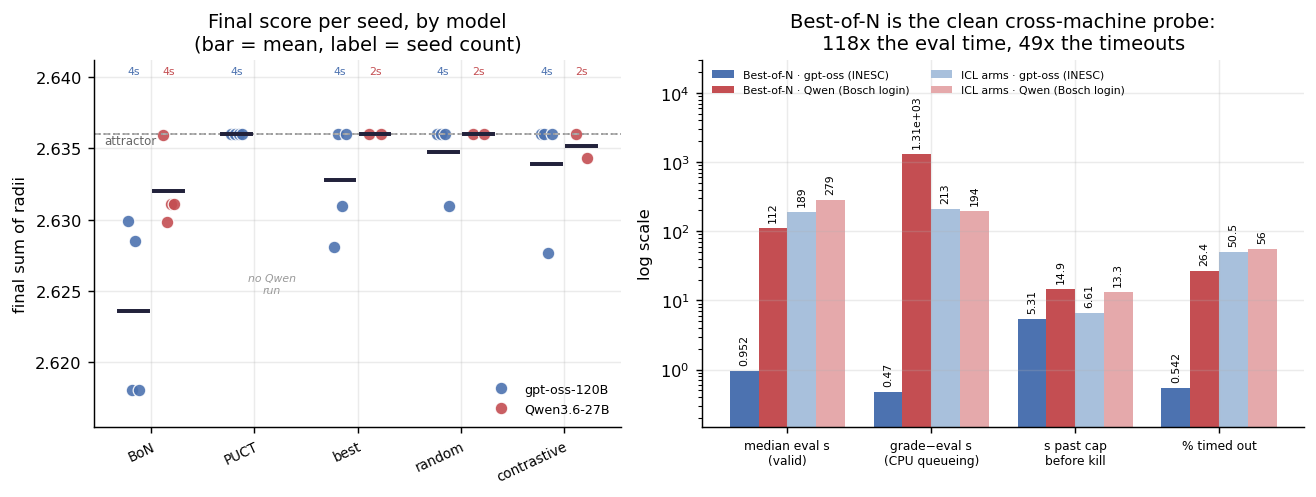

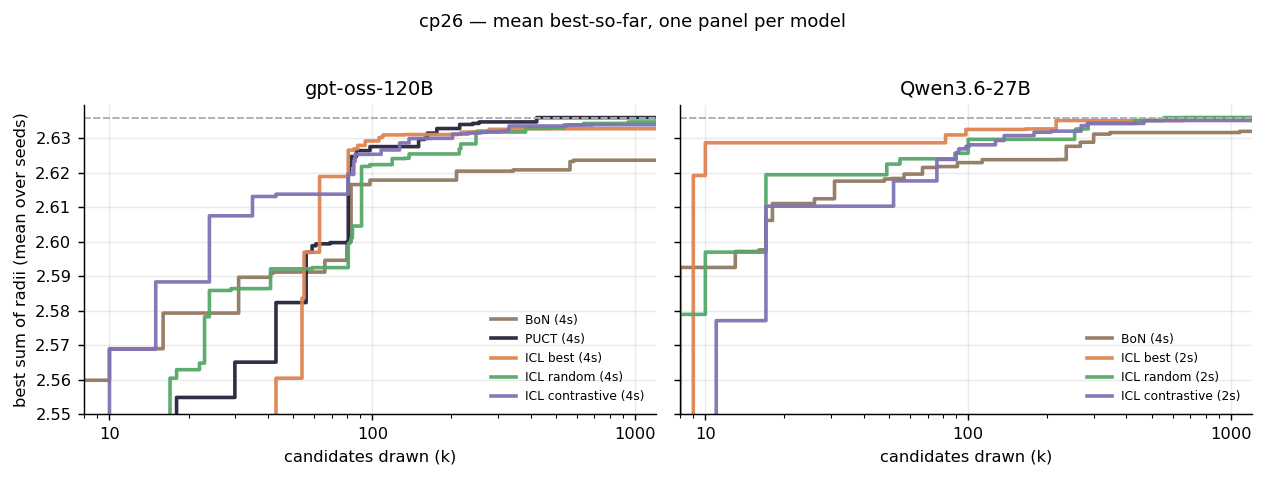

In [13]:
MODELS = ("gpt-oss-120B", "Qwen3.6-27B")
CMODEL = {"gpt-oss-120B": "#4C72B0", "Qwen3.6-27B": "#C44E52"}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.2, 3.9), gridspec_kw={"width_ratios": [1.05, 1.2]})

# LEFT: the §1 dot plot, split by model -- final score of every seed, side by side per arm.
for i, a in enumerate(ARMS_CP):
    for j, model in enumerate(MODELS):
        cs = curves(CP, model, a)
        xo = i + (j - .5) * .34
        if not cs:
            axL.text(xo, 2.6255, "no Qwen\nrun", ha="center", va="center", fontsize=6,
                     color="#999", style="italic")
            continue
        f = np.array([c[-1] for c in cs.values()])
        axL.plot(xo + np.linspace(-.055, .055, len(f)), f, "o", ms=7, color=CMODEL[model],
                 alpha=.9, mec="white", mew=.7,
                 label=model if i == 0 else None)
        axL.plot([xo - .14, xo + .14], [f.mean()] * 2, lw=2.2, color=CMEAN, zorder=3)
        axL.text(xo, 2.6402, f"{len(f)}s", ha="center", fontsize=6, color=CMODEL[model])
axL.axhline(TARGET[CP], ls="--", lw=1, color=CREF)
axL.axhline(ATTRACTOR, ls=":", lw=1, color="#999")
axL.text(-.45, ATTRACTOR, "attractor", fontsize=6.5, color="#666", va="top")
axL.set(xlim=(-.55, 4.55), ylim=(2.6155, 2.6412), xticks=range(len(ARMS_CP)),
        xticklabels=[a.replace("ICL ", "") for a in ARMS_CP], ylabel="final sum of radii",
        title="Final score per seed, by model\n(bar = mean, label = seed count)")
axL.tick_params(axis="x", labelsize=7.5)
plt.setp(axL.get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")
axL.legend(fontsize=7, loc="lower right")

# Infra probes. Best-of-N is the clean comparison: the same arm on both machines, and (per §5) the one
# arm with no runtime inflation, so anything that differs is the box. The ICL arms are shown next to it
# to make the point that there the two effects stack and the infra gap is masked.
pr = []
for model in ("gpt-oss-120B", "Qwen3.6-27B"):
    for grp, arms in (("Best-of-N", ["BoN"]), ("ICL arms", ["ICL best", "ICL random", "ICL contrastive"])):
        ds = [d for a in arms for _, d in arm_runs(CP, model, a)]
        if not ds:
            continue
        n = sum(len(d) for d in ds)
        pr.append(dict(model="gpt-oss" if "gpt" in model else "Qwen", grp=grp,
                       valid_eval=np.median([d[d.valid].eval_seconds.median() for d in ds]),
                       queueing=np.median([(d.grade_seconds - d.eval_seconds).median() for d in ds]),
                       kill_over=np.nanmedian([(d[d.failure_type == "eval_timeout"].eval_seconds
                                                - CAP[CP]).median() for d in ds]),
                       timeout_pct=100 * sum(int((d.failure_type == "eval_timeout").sum()) for d in ds) / n))
PR = pd.DataFrame(pr)
metrics = [("valid_eval", "median eval s\n(valid)"), ("queueing", "grade−eval s\n(CPU queueing)"),
           ("kill_over", "s past cap\nbefore kill"), ("timeout_pct", "% timed out")]
x = np.arange(len(metrics)); w = .2
bars = [("Best-of-N", "gpt-oss", "#4C72B0", -1.5), ("Best-of-N", "Qwen", "#C44E52", -.5),
        ("ICL arms", "gpt-oss", "#A8C0DC", .5), ("ICL arms", "Qwen", "#E5A9AB", 1.5)]
for grp, mdl, col, off in bars:
    row = PR[(PR.grp == grp) & (PR.model == mdl)]
    if row.empty:
        continue
    v = [row[k].iloc[0] for k, _ in metrics]
    axR.bar(x + off * w, v, w, color=col,
            label=f"{grp} · {mdl} ({'INESC' if mdl == 'gpt-oss' else 'Bosch login'})")
    for xi, vi in zip(x + off * w, v):
        axR.text(xi, vi * 1.3, f"{vi:.3g}", ha="center", fontsize=6, rotation=90)
bon = PR[PR.grp == "Best-of-N"].set_index("model")
axR.set(xticks=x, xticklabels=[lab for _, lab in metrics], yscale="log", ylim=(.15, 30000),
        ylabel="log scale",
        title=f"Best-of-N is the clean cross-machine probe:\n"
              f"{bon.loc['Qwen', 'valid_eval'] / bon.loc['gpt-oss', 'valid_eval']:.0f}x the eval time, "
              f"{bon.loc['Qwen', 'timeout_pct'] / bon.loc['gpt-oss', 'timeout_pct']:.0f}x the timeouts")
axR.tick_params(axis="x", labelsize=6.8)
axR.legend(fontsize=6, ncol=2, loc="upper left")
fig.savefig("mf_qwen.png", dpi=200, bbox_inches="tight")

# Small multiples: each model's arms on its own axis, so the two panels can be compared directly
# without eight overlapping lines on one plot.
fig2, axes2 = plt.subplots(1, 2, figsize=(9.8, 3.5), sharey=True)
for ax, model in zip(axes2, MODELS):
    for a in ARMS_CP:
        cs = curves(CP, model, a)
        if not cs:
            continue
        ax.step(np.arange(1, BUDGET + 1), mean_curve(cs), where="post", lw=2.0,
                color=CARM[a], alpha=.95, label=f"{a} ({len(cs)}s)")
    ax.axhline(ATTRACTOR, ls=":", lw=1, color="#999")
    ax.axhline(TARGET[CP], ls="--", lw=1, color=CREF)
    ax.set(xscale="log", xlim=(8, BUDGET), ylim=(2.55, 2.6395), xlabel="candidates drawn (k)",
           title=model)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.legend(fontsize=6.8, loc="lower right")
axes2[0].set_ylabel("best sum of radii (mean over seeds)")
fig2.suptitle("cp26 — mean best-so-far, one panel per model", y=1.03, fontsize=10)
fig2.savefig("mf_model_curves.png", dpi=200, bbox_inches="tight")

print(PR.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\nfinal score per arm, gpt-oss vs Qwen (mean over available seeds)")
cmp_rows = []
for a in ARMS_CP:
    r = {"arm": a}
    for model in MODELS:
        cs = curves(CP, model, a)
        f = [c[-1] for c in cs.values()]
        r["gpt-oss" if "gpt" in model else "Qwen"] = f"{np.mean(f):.5f} ({len(f)}s)" if f else "—"
    g = [c[-1] for c in curves(CP, MODELS[0], a).values()]
    q = [c[-1] for c in curves(CP, MODELS[1], a).values()]
    r["Qwen − gpt-oss"] = f"{np.mean(q) - np.mean(g):+.5f}" if q and g else "—"
    cmp_rows.append(r)
print(pd.DataFrame(cmp_rows).to_string(index=False))

print("\nfinal score and speed, cp26 (median k to reach each threshold)")
for model in ("gpt-oss-120B", "Qwen3.6-27B"):
    for a in ARMS_CP:
        cs = curves(CP, model, a)
        if not cs:
            continue
        f = [c[-1] for c in cs.values()]
        ks = []
        for t, lab in zip([2.62, 2.63, ATTRACTOR - 1e-6], ["2.62", "2.63", "attr"]):
            got = [k for k in (k_to(c, t) for c in cs.values()) if k]
            ks.append(f"{lab}@k={int(np.median(got)) if got else '—':>4} ({len(got)}/{len(cs)})")
        print(f"  {model:<13} {a:<17} final {np.mean(f):.5f} ({len(f)} seeds)   " + "  ".join(ks))
tok = INV[INV.arm == "BoN"].groupby("model")[["compl_tok", "truncated"]].mean()
print("\nBoN token spend per run (same 1,200 candidates):\n"
      + tok.to_string(float_format=lambda v: f"{v:,.0f}"))

**Finding 8 — the Bosch runs are usable for scores and unusable for failure rates.**

Same problem, same Best-of-N arm, two machines: median valid eval **0.95s on `guadiana` vs 112.1s on
the login node — 118x**; CPU-group queueing **0.47s vs 1,306s**; time-to-kill **5.3s vs 14.9s**;
timeout rate **0.54% vs 26.4%, a factor of 49**. Nothing about the arm changed — only the box.

Best-of-N is the right probe precisely because §5 showed it is the one arm whose programs do not
inflate. On the ICL arms the same cross-machine comparison is only 189s vs 279s (1.5x) — not because
the login node is fine there, but because runtime inflation has already pushed both machines against
the cap, so the infra penalty is hidden inside a larger effect. **The two mechanisms stack**, which is
why the ICL arms on Bosch lose 56% of their candidates.

With that caveat in place, the score comparison is worth having — and **Qwen3.6-27B is ahead of
gpt-oss-120B on every arm the two share**, despite running on the crippled node and losing 26–61% of
its candidates to it:

| arm | gpt-oss-120B | Qwen3.6-27B | Qwen − gpt-oss |
|---|---|---|---|
| Best-of-N | 2.62363 (4 seeds) | **2.63200** (4 seeds) | **+0.0084** |
| ICL best | 2.63275 (4) | **2.63598** (2) | +0.0032 |
| ICL random | 2.63473 (4) | **2.63598** (2) | +0.0013 |
| ICL contrastive | 2.63391 (4) | **2.63514** (2) | +0.0012 |
| PUCT | 2.63598 (4) | — never run | — |

Qwen's ICL arms all land at or within 1e-5 of the attractor, where gpt-oss's `ICL best` got there in
2/4 seeds. Qwen is faster early too — `ICL best` clears 2.62 by a median k=6 and 2.63 by k=46, against
gpt-oss's k=72 / k=85 — though on 2 seeds.

**Be careful how far this is pushed.** Every delta in that table, including the +0.0084 on Best-of-N,
is *below* the 0.0106 that §3 showed 4 seeds can resolve, and the Qwen ICL rows have 2 seeds rather
than 4. The interesting part is the **consistency of the sign across four independent arms**, not any
individual gap. It is also not free: **17.7M completion tokens per BoN run against gpt-oss's 4.8M
(3.7x)**, with ~10 truncated completions per run — so at matched *token* budget rather than matched
candidate count the comparison could invert. That is exactly the fixed-compute-budget question the
project is built around, and these runs cannot answer it. Re-running the Qwen arms on an INESC box,
with 4 seeds and a PUCT arm, is the cheapest way to make model scale a real datapoint.

## Summary

| | |
|---|---|
| **cp26, gpt-oss (4 seeds)** | PUCT **2.63598** (4/4 at attractor) > ICL random 2.63473 (3/4) > contrastive 2.63391 (3/4) > best 2.63275 (2/4) > BoN **2.62363** (0/4) |
| **cp26 convergence** | median gap left at k=80: **ICL best 0.0126** < PUCT 0.0180 < BoN 0.0194 < contrastive 0.0214 < random 0.0319. Crossover at k≈160; PUCT is the only arm with all 4 seeds there (k=150–422); `best` gets one there first (k=122) but loses 2 entirely |
| **cp26 resolution** | seed sd 0.0045 → smallest detectable 2-arm gap **0.0106**. Only 2 of 10 pairwise gaps clear it (BoN vs PUCT 0.0124, BoN vs random 0.0111); every PUCT-vs-ICL gap is 0.0013–0.0032 ✗. PUCT is 2e-5 from target with sd 6e-13 |
| **cp26 timeouts** | **the solutions**: survivors' median eval 1.3s → 419s (**332x**), and slow *is* better (P(≥2.63) 1%→46%, ρ=0.55). BoN, same box, same hours: **1.0x drift, 0.54% timeouts vs 52.7%** |
| **ac1 timeouts** | **the scaffold**: `budget_s`=1000 vs an 1100s cap; median eval 1004s on all 5 hosts (3% spread) but timeout rate spans 0.5%–32.8% (66x). Predicted by survivor p90, and by host |
| **ac1, gpt-oss** | **PUCT 1.51515 ± 0.00109 ≈ BoN 1.51543 ± 0.00254** (4 seeds each — search buys nothing). 3 of 5 full-budget ICL runs beat all 8, best `n10 best` **1.50643** — but ICL spans 0.010, **1 seed per config** |
| **cost of context** | prefill/candidate 57 (BoN) → 220 (PUCT) → 1,839 (ICL best) = 8.4x PUCT for no cp26 gain; reasoning share 0.75 → 0.22 once a parent is in the prompt |
| **Qwen** | all runs on the Bosch login node: eval 112s vs 0.95s, queueing 1,306s vs 0.47s, 26.4% vs 0.54% timeouts. Scores readable (BoN 2.63200 > gpt-oss 2.62363, and 2.62 by k=6) — failure counts not. 3.7x the tokens |

### Actions, in priority order

1. **Tell the cp26 prompt about the eval budget**, as `ac1` already does, and/or surface each
   candidate's eval time in the feedback. Without it, PUCT optimises straight into the timeout wall by
   generation 4–5 and then discards half of every generation — including, per §5(b), the best
   candidates it has. This is the single change most likely to move cp26 results.
2. **Fix the ac1 margin**: cap at ~1.5x `budget_s`, or drop `budget_s` to ~700. Until then no ac1
   failure count can be attributed to an arm, and ac1 *scores* are pessimistic by an unknown amount
   for the unlucky runs — which is the §7 ranking.
3. **Seeds where the signal is**: 4 seeds per ac1 ICL configuration. `PUCT ≈ BoN` on ac1 is already
   solid on 4 seeds; whether ICL beats both is the only claim in the campaign that would change the
   story, and it rests on n=1 with a spread 9x PUCT's seed sd.
4. **Never run the driver on the Bosch login node** — use `src/jobs/*.bsub`, or
   `ray start --head --num-cpus=5` as an interim. Then re-run the Qwen arms so model scale becomes a
   real datapoint rather than a caveat.
5. **Stop ranking arms on cp26.** Report k-to-threshold there and move discrimination to ac1 and cp32.
6. **Re-run cp26 PUCT and ICL on one box.** PUCT is on `guadiana` and the ICL arms on `vouga`, so the
   headline PUCT-vs-ICL gap — which §3 says is unresolvable anyway — also crosses machines.
7. **Decide what "fixed compute budget" means** before the next round. §8 shows matched candidates is
   not matched tokens (8.4x prefill) and not matched reasoning (0.75 → 0.22), and §9 shows Qwen spends
   3.7x gpt-oss's decode for the same 1,200 candidates.